# Recovering Bursty Star Formation Histories

The core capability of tengri: recovering bursty SFH features that
parametric models miss. Plus the "wrong model trap" — fitting a bursty
galaxy with a smooth model looks fine in chi-squared but gives wrong SFRs.

In [1]:
import time
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri import (
    Fitter,
    Fixed,
    Model,
    Observation,
    Parameters,
    Photometry,
    Uniform,
    load_ssp_data,
)
from tengri.models.observation import Spectroscopy

import sys, os  # noqa: E401

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))
except NameError:
    _nb_dir = os.getcwd()
    sys.path.insert(0, os.path.join(_nb_dir, ".."))
# Change to project root so data/ paths work
# chdir to project root for data/ access
if os.path.exists("data"):
    pass  # already in project root
elif os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
elif os.path.exists(os.path.join("..", "..", "data")):
    os.chdir(os.path.join("..", ".."))
elif os.path.exists(os.path.join("..", "..", "..", "data")):
    os.chdir(os.path.join("..", "..", ".."))

FIGDIR = os.path.join("quickstart", "figures")
os.makedirs(FIGDIR, exist_ok=True)

from _plot_style import (
    COLORS,
    add_sfh_inset,
    convergence_table,
    plot_corner_comparison,
    plot_sfh,
    safe_corner,
    setup_style,
)

setup_style()

In [2]:
ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
WAVE_OBS = jnp.linspace(3800.0, 9200.0, 200)
FILTER_NAMES = ["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"]
obs_spec = Observation(spectroscopy=Spectroscopy(wave_obs=WAVE_OBS))
obs_joint = Observation(
    photometry=Photometry.from_names(FILTER_NAMES),
    spectroscopy=Spectroscopy(wave_obs=WAVE_OBS),
)

## The Four Burstiness Regimes

| Regime | σ_PS | τ_PS | Physical analogy |
|--------|------|------|-----------------|
| Smooth | 0.3 | 100 Myr | Secular disk evolution |
| Moderate | 1.0 | 50 Myr | Gas cycling, minor mergers |
| Bursty | 2.0 | 20 Myr | SN feedback dominance |
| Extreme | 3.0 | 5 Myr | Dwarf starburst, first galaxies |

In [3]:
REGIMES = [
    {"sigma": 0.3, "tau": 100, "label": "Smooth"},
    {"sigma": 1.0, "tau": 50, "label": "Moderate"},
    {"sigma": 2.0, "tau": 20, "label": "Bursty"},
    {"sigma": 3.0, "tau": 5, "label": "Extreme"},
]

spec_stoch = Parameters(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    sfh_field_psd_sigma=Uniform(0.1, 4.0),
    sfh_field_psd_tau_myr=Uniform(1.0, 300.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    mean_sfh_type=["tsnorm", "field"],
    n_grid=128,
)
model_stoch = Model(spec_stoch, ssp_data, observation=obs_spec)

W0405 02:40:08.888923 36250892 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.
/Users/suchethacooray/Projects/diffsed/src/tengri/core/model.py:591: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  self.precompute_spectroscopy(observation.spectroscopy.wave_obs)


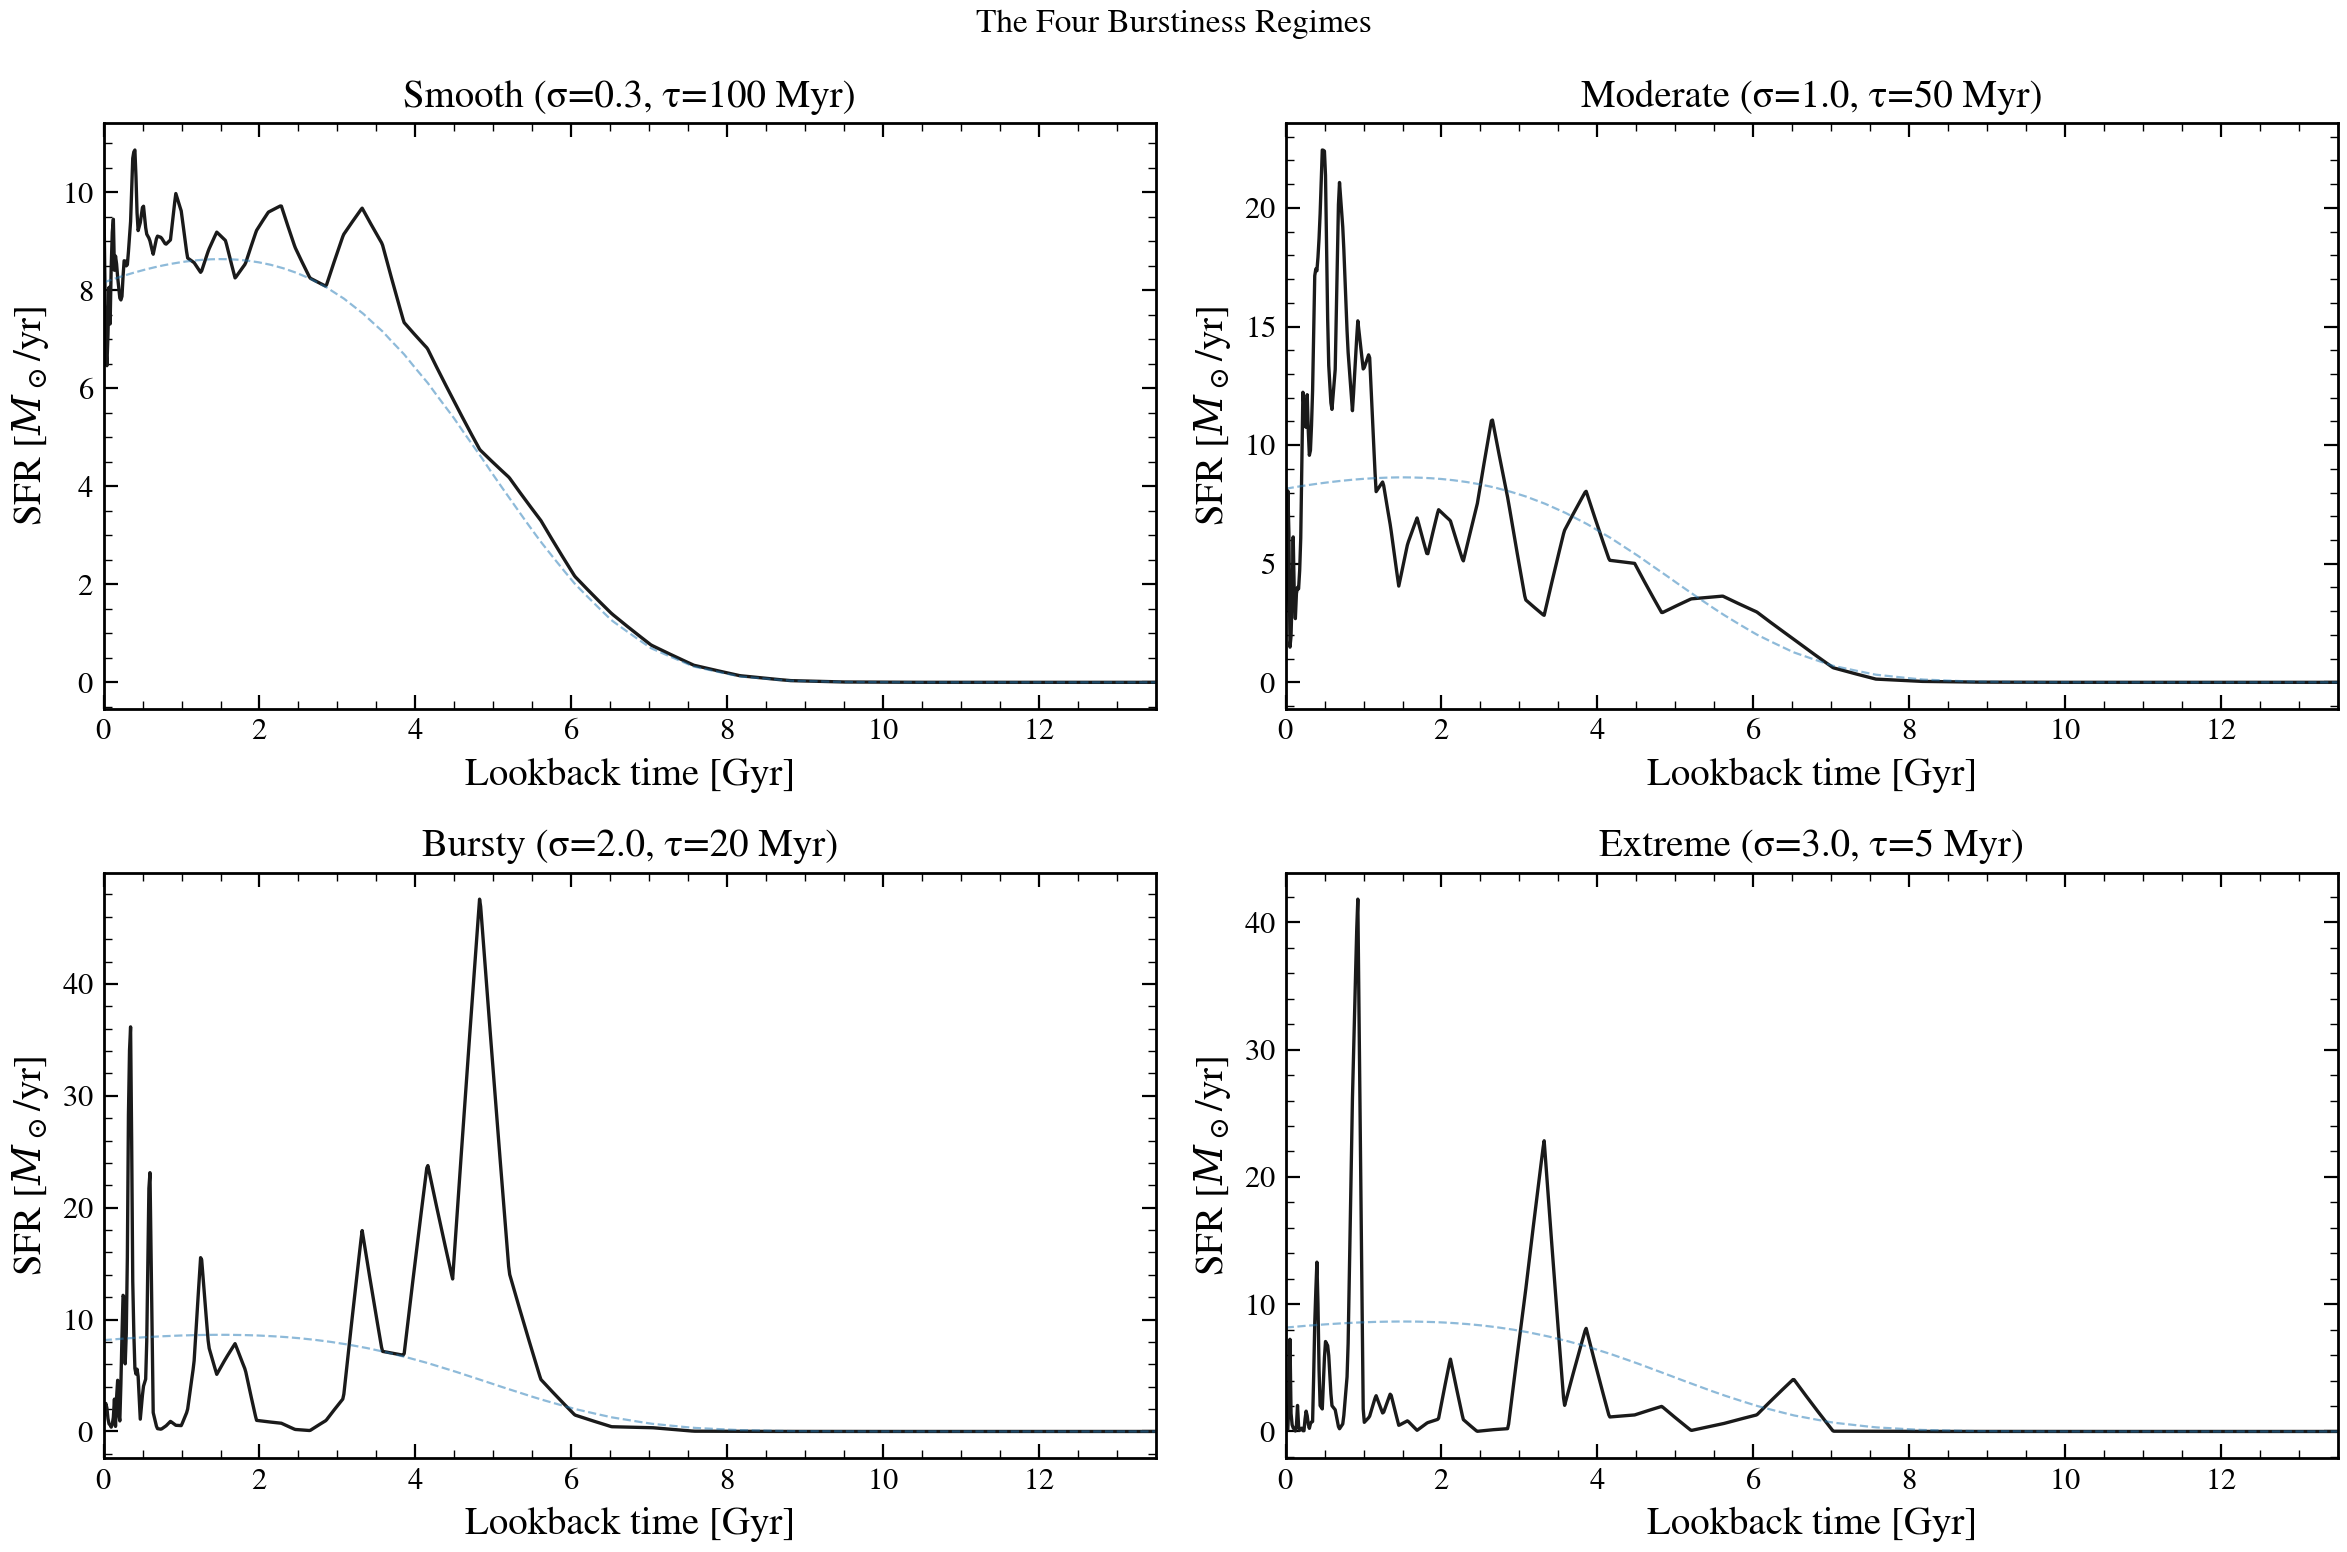

In [4]:
# --- FIGURE 1: 2×2 SFH showcase ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
regime_data = {}

for ax, reg in zip(axes.flat, REGIMES):
    key = jax.random.PRNGKey(abs(hash(reg["label"])) % 2**31)
    true_p = spec_stoch.sample(key)
    # Override to a typical star-forming galaxy with regime-specific burstiness
    true_p = {**true_p}
    true_p["sfh_tsnorm_log_peak_sfr"] = jnp.array(1.2)
    true_p["sfh_tsnorm_peak_lbt_gyr"] = jnp.array(3.0)
    true_p["sfh_tsnorm_width_gyr"] = jnp.array(3.0)
    true_p["sfh_tsnorm_skew"] = jnp.array(0.3)
    true_p["sfh_tsnorm_trunc"] = jnp.array(2.0)
    true_p["sfh_field_psd_sigma"] = jnp.array(reg["sigma"])
    true_p["sfh_field_psd_tau_myr"] = jnp.array(float(reg["tau"]))

    sfh = model_stoch.predict_sfh(true_p)
    t_gyr = np.array(sfh["t_gyr"])
    sfr_full = np.array(sfh["sfr_full"])
    sfr_mean = np.array(sfh["sfr_mean"])

    ax.plot(t_gyr, sfr_full, color=COLORS["truth"], lw=1.2)
    ax.plot(t_gyr, sfr_mean, color=COLORS["sfh_mean"], lw=0.8, ls="--", alpha=0.5)
    ax.set_xlim(0, 13.5)
    ax.set_xlabel("Lookback time [Gyr]")
    ax.set_ylabel(r"SFR [$M_\odot$/yr]")
    ax.set_title(f"{reg['label']} (σ={reg['sigma']}, τ={reg['tau']} Myr)")

    regime_data[reg["label"]] = {"params": true_p, "sfh": sfh}

fig.suptitle("The Four Burstiness Regimes", fontsize=12)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig01_burstiness_regimes.png"), dpi=150, bbox_inches="tight")
plt.show()

## Recovery from Spectroscopy

In [5]:
# Fit each regime
regime_results = {}
for reg in REGIMES:
    true_p = regime_data[reg["label"]]["params"]
    mock = model_stoch.mock_spectrum(
        true_p,
        WAVE_OBS,
        snr=30.0,
        key=jax.random.PRNGKey(abs(hash(reg["label"])) % 2**31 + 1),
    )
    fitter = Fitter(model_stoch, mock.flux_obs, mock.noise)
    _ = fitter.run("map", n_steps=1000, verbose=False)
    res = fitter.run(
        "vi",
        n_iterations=15,
        n_samples=6,
        n_seeds=3,
        n_posterior_samples=2000,
        verbose=False,
    )
    regime_results[reg["label"]] = res
    print(f"  {reg['label']}: {res.wall_time_s:.1f}s")

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


W0405 02:40:12.992966 36250764 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0405 02:40:15.135610 36250764 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

  Moderate: 20.3s


/Users/suchethacooray/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Seeds disagree: H = 106.7 ± 11.1 (CV=10%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return run_native_vi(self, key=key, **kwargs)


  Bursty: 17.8s


/Users/suchethacooray/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Seeds disagree: H = 126.5 ± 20.1 (CV=16%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return run_native_vi(self, key=key, **kwargs)


  Extreme: 17.5s


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_79273/117828991.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


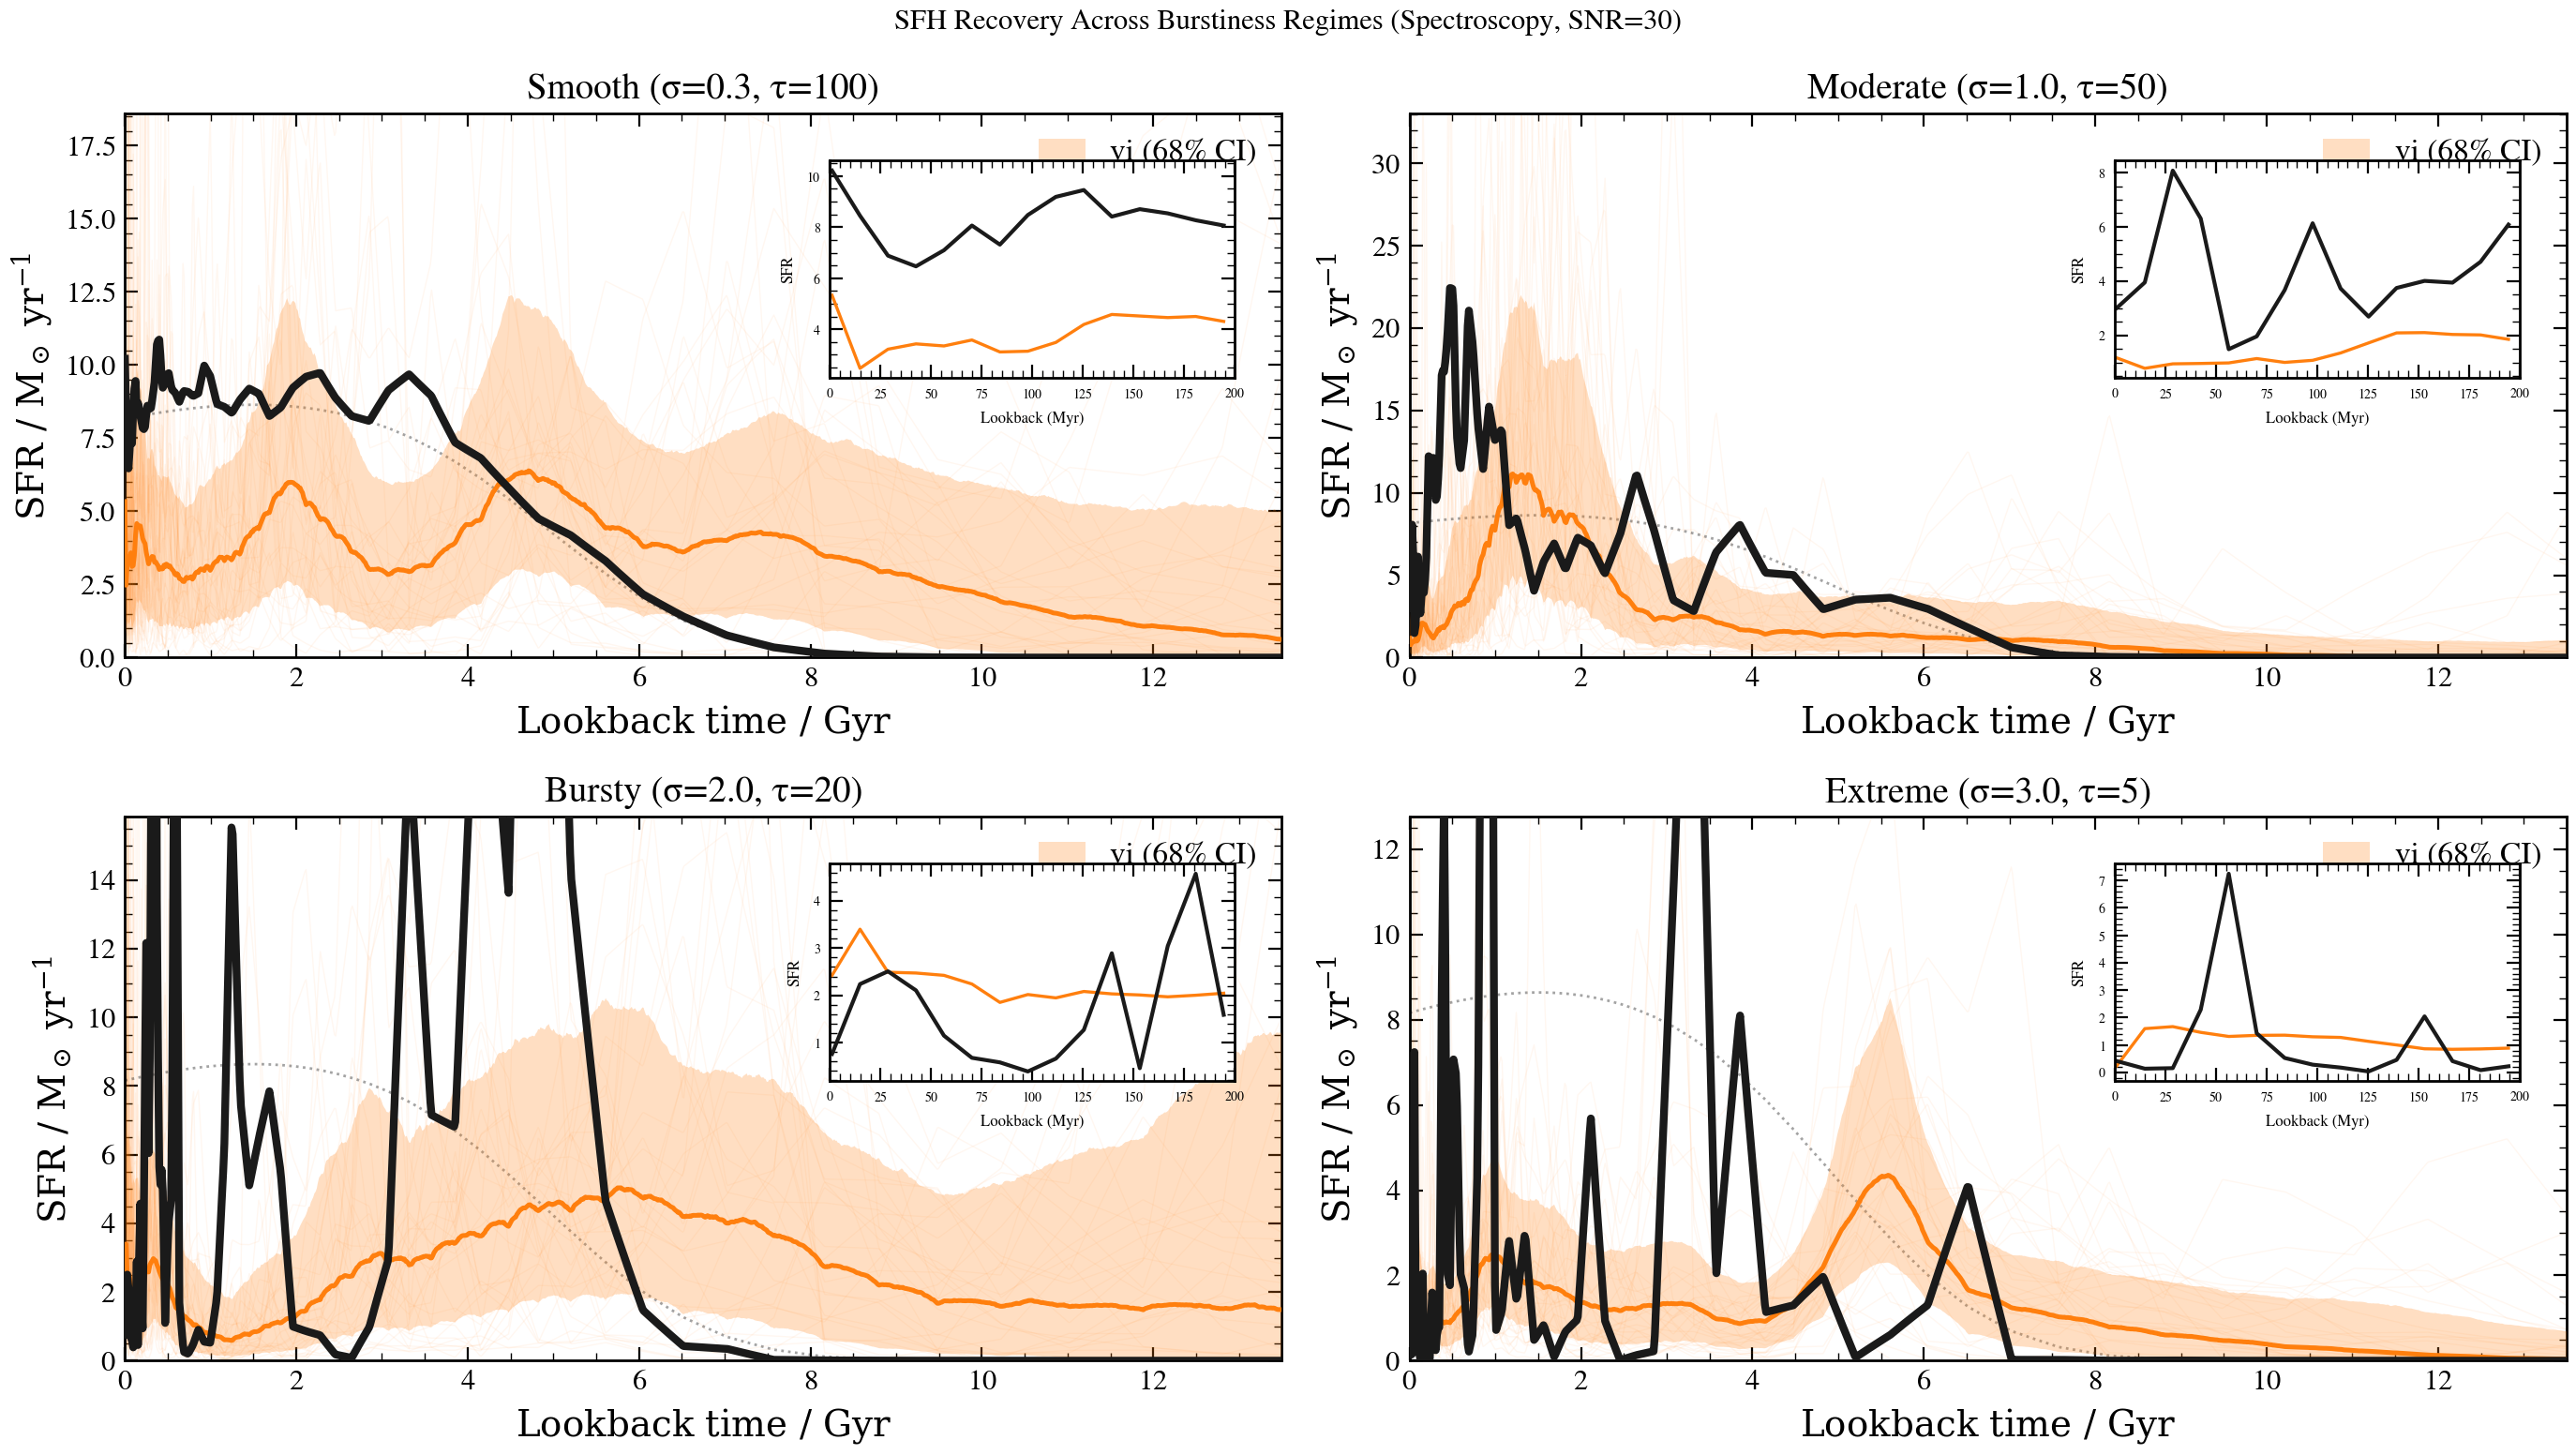

In [6]:
# --- FIGURE 2: 4-panel SFH recovery ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, reg in zip(axes.flat, REGIMES):
    true_p = regime_data[reg["label"]]["params"]
    plot_sfh(
        model_stoch,
        regime_results[reg["label"]],
        true_params=true_p,
        ax=ax,
        color=COLORS["geovi"],
        label="vi",
        method="geoVI",
        show_mean_sfh=True,
    )
    ax.set_title(f"{reg['label']} (σ={reg['sigma']}, τ={reg['tau']})")

fig.suptitle("SFH Recovery Across Burstiness Regimes (Spectroscopy, SNR=30)", fontsize=11)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig02_sfh_recovery_4regimes.png"), dpi=150, bbox_inches="tight")
plt.show()

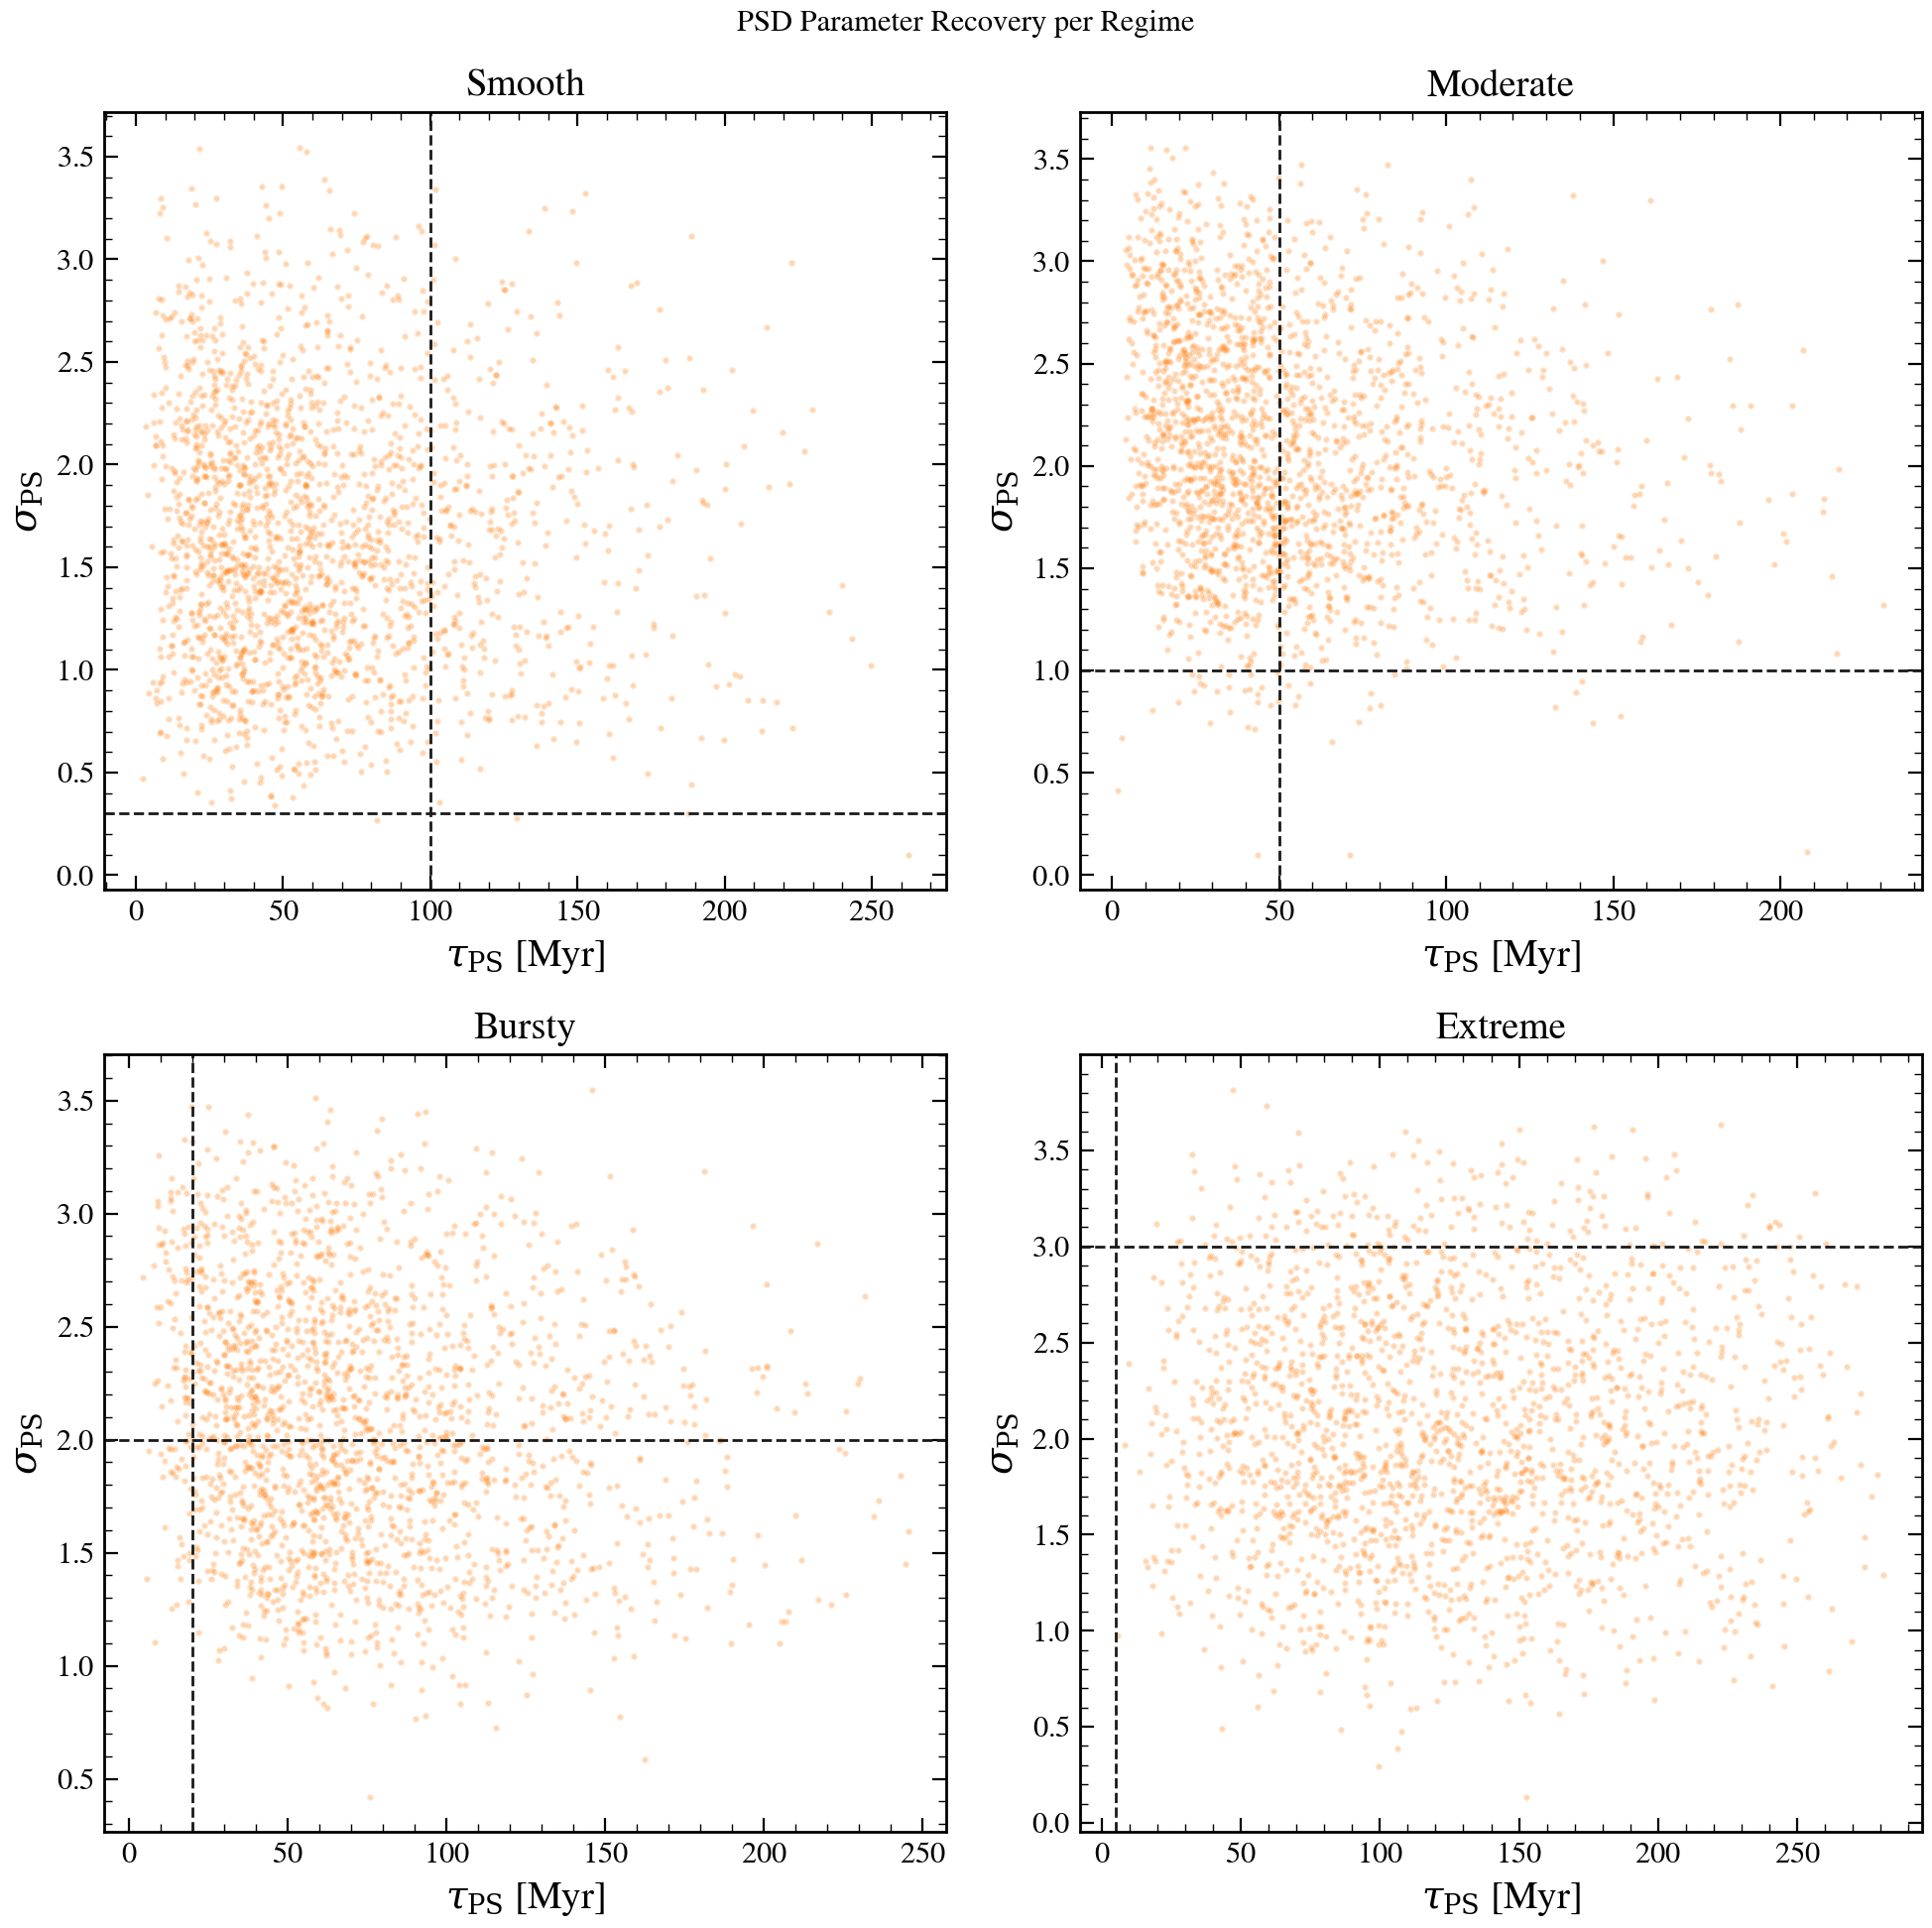

In [7]:
# --- FIGURE 3: PSD corner per regime ---
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
psd_params = ["sfh_field_psd_sigma", "sfh_field_psd_tau_myr"]
for ax, reg in zip(axes.flat, REGIMES):
    res = regime_results[reg["label"]]
    true_p = regime_data[reg["label"]]["params"]
    sig_s = np.array(res.samples["sfh_field_psd_sigma"])
    tau_s = np.array(res.samples["sfh_field_psd_tau_myr"])
    ax.scatter(tau_s, sig_s, s=2, alpha=0.2, color=COLORS["geovi"])
    ax.axhline(float(true_p["sfh_field_psd_sigma"]), color=COLORS["truth"], ls="--", lw=1)
    ax.axvline(float(true_p["sfh_field_psd_tau_myr"]), color=COLORS["truth"], ls="--", lw=1)
    ax.set_xlabel(r"$\tau_{\rm PS}$ [Myr]")
    ax.set_ylabel(r"$\sigma_{\rm PS}$")
    ax.set_title(reg["label"])

fig.suptitle("PSD Parameter Recovery per Regime", fontsize=11)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig03_psd_corners.png"), dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Convergence diagnostics — all four regimes
print(convergence_table(regime_results, verbose=True))

Method           ESS min  ESS med    τ max   Accept   Diverg     Status
-----------------------------------------------------------------------
Smooth              1303     1532      1.5        —        —         OK
Moderate            1462     1578      1.4        —        —         OK
Bursty              1453     1552      1.4        —        —         OK
Extreme             1457     1546      1.4        —        —         OK
{'Smooth': {'ess_min': 1302.6486889111288, 'ess_median': 1532.0396326291852, 'n_params_low_ess': 0, 'tau_max_max': 1.5353333688699908, 'tau_max_median': 1.3055156410497002, 'n_params_short_chain': 0, 'converged': True, 'warnings': []}, 'Moderate': {'ess_min': 1462.3337099260343, 'ess_median': 1577.6977575251228, 'n_params_low_ess': 0, 'tau_max_max': 1.3676768759581979, 'tau_max_median': 1.2676991777521622, 'n_params_short_chain': 0, 'converged': True, 'warnings': []}, 'Bursty': {'ess_min': 1452.995116365691, 'ess_median': 1551.5506365210913, 'n_params_low_ess': 

In [9]:
# Parameter recovery table — Bursty regime (physical params only)
bursty_res = regime_results["Bursty"]
bursty_params = regime_data["Bursty"]["params"]
phys_params = [p for p in spec_stoch.free_params if "xi" not in p]
print(f"\n{'Parameter':<32s} {'True':>8s} {'Median':>8s} {'16%':>8s} {'84%':>8s} {'Status':>6s}")
print("-" * 76)
for name in phys_params:
    truth = float(bursty_params[name])
    lo, med, hi = np.percentile(bursty_res.samples[name], [16, 50, 84])
    covered = "ok" if lo <= truth <= hi else "MISS"
    print(f"  {name:<30s} {truth:8.3f} {med:8.3f} {lo:8.3f} {hi:8.3f} {covered:>6s}")


Parameter                            True   Median      16%      84% Status
----------------------------------------------------------------------------
  dust_tau_bc                       0.492    0.997    0.846    1.155   MISS
  dust_tau_diff                     1.469    1.028    0.925    1.125   MISS
  met_logzsol                       0.118   -0.120   -0.183   -0.065   MISS
  sfh_field_psd_sigma               2.000    2.067    1.463    2.691     ok
  sfh_field_psd_tau_myr            20.000   64.760   33.594  118.708   MISS
  sfh_tsnorm_log_peak_sfr           1.200    1.611    1.208    2.022   MISS
  sfh_tsnorm_peak_lbt_gyr           3.000    5.006    3.118    7.546   MISS
  sfh_tsnorm_skew                   0.300   -0.184   -0.834    0.187   MISS
  sfh_tsnorm_trunc                  2.000    5.935    3.789    7.844   MISS
  sfh_tsnorm_width_gyr              3.000    3.070    2.059    4.035     ok


## Elliptical Slice Sampling vs geoVI: Bursty Regime

ESS (Murray, Adams & MacKay 2010) is an exact MCMC method for models with
Gaussian priors on latent variables. It proposes along prior ellipses — no
step-size tuning. We compare it to geoVI on the "Bursty" regime (σ=2, τ=20 Myr).

In [10]:
bursty_mock_ess = model_stoch.mock_spectrum(
    regime_data["Bursty"]["params"],
    WAVE_OBS,
    snr=30.0,
    key=jax.random.PRNGKey(abs(hash("Bursty")) % 2**31 + 1),
)
fitter_ess = Fitter(model_stoch, bursty_mock_ess.flux_obs, bursty_mock_ess.noise)
_ = fitter_ess.run("map", n_steps=1000, verbose=False)
result_ess = fitter_ess.run(
    "mcmc_ess",
    n_samples=2000,
    n_burnin=300,
    verbose=False,
)
print(f"  ESS: {result_ess.wall_time_s:.1f}s")

  ESS: 4.2s


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_79273/1045687622.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


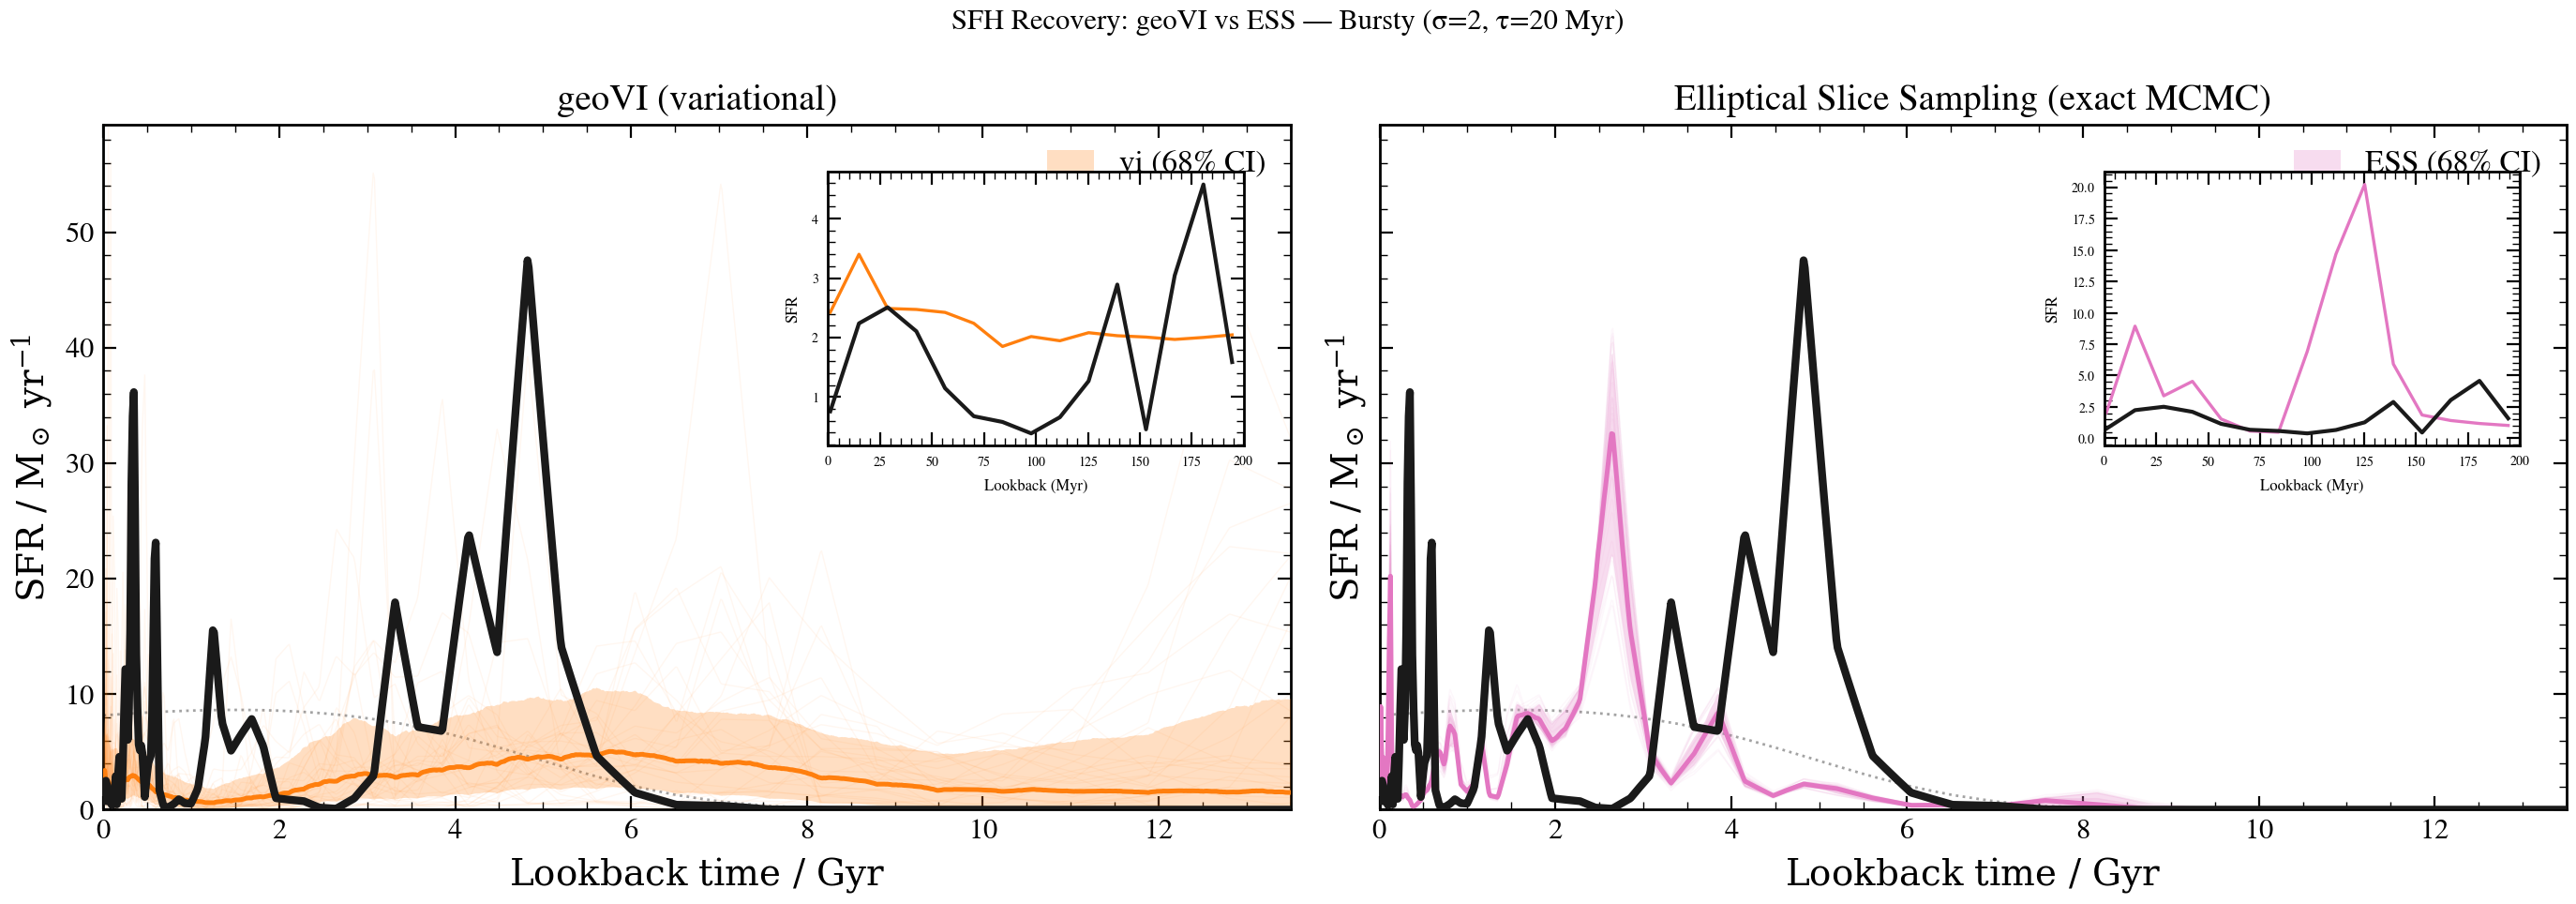

In [11]:
# --- FIGURE 4: geoVI vs ESS SFH recovery (Bursty regime) ---
fig, (ax_gv, ax_ess) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

bursty_true_p = regime_data["Bursty"]["params"]

plot_sfh(
    model_stoch,
    regime_results["Bursty"],
    true_params=bursty_true_p,
    ax=ax_gv,
    color=COLORS["geovi"],
    label="vi",
    method="geoVI",
    show_mean_sfh=True,
)
ax_gv.set_title("geoVI (variational)")

plot_sfh(
    model_stoch,
    result_ess,
    true_params=bursty_true_p,
    ax=ax_ess,
    color=COLORS["ess"],
    label="ESS",
    method="ESS",
    show_mean_sfh=True,
)
ax_ess.set_title("Elliptical Slice Sampling (exact MCMC)")

fig.suptitle("SFH Recovery: geoVI vs ESS — Bursty (σ=2, τ=20 Myr)", fontsize=11)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig04_ess_vs_geovi_sfh.png"), dpi=150, bbox_inches="tight")
plt.show()

/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.1

/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.1

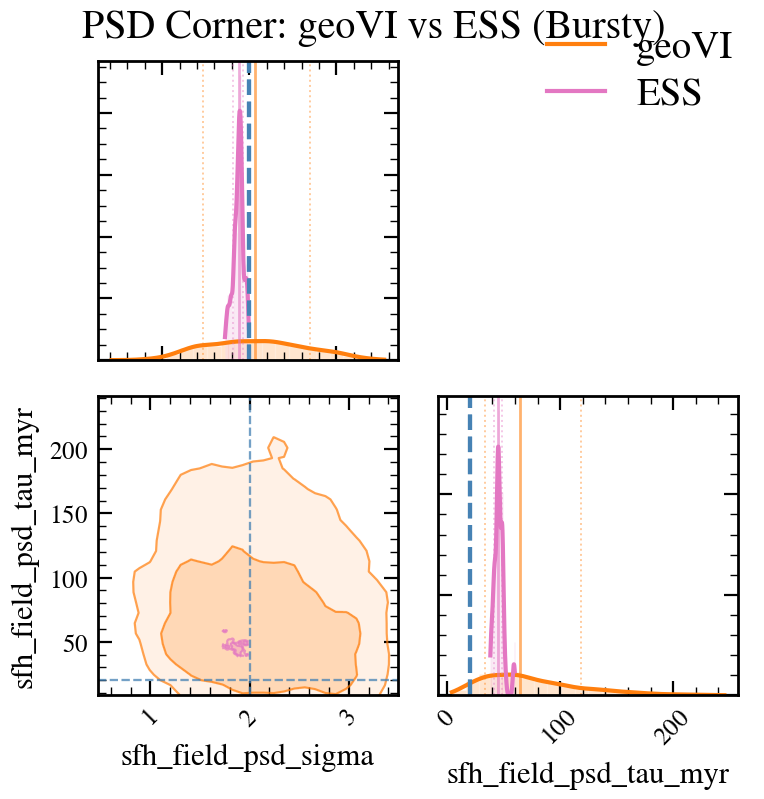

In [12]:
# Corner: PSD parameters — geoVI vs ESS
fig = plot_corner_comparison(
    [regime_results["Bursty"], result_ess],
    labels=["geoVI", "ESS"],
    colors=[COLORS["geovi"], COLORS["ess"]],
    truths=bursty_true_p,
    params=["sfh_field_psd_sigma", "sfh_field_psd_tau_myr"],
)
if fig is not None:
    fig.suptitle("PSD Corner: geoVI vs ESS (Bursty)", y=1.02)
    plt.savefig(
        os.path.join(FIGDIR, "fig04b_ess_vs_geovi_corner.png"),
        dpi=150,
        bbox_inches="tight",
    )
plt.show()

In [13]:
# Convergence comparison
print(
    convergence_table(
        {"geoVI (Bursty)": regime_results["Bursty"], "ESS (Bursty)": result_ess},
        verbose=True,
    )
)

Method           ESS min  ESS med    τ max   Accept   Diverg     Status
-----------------------------------------------------------------------
geoVI (Bursty)      1453     1552      1.4        —        —         OK
ESS (Bursty)           1        1   2856.0        —        —       WARN

Warnings:
  [ESS (Bursty)] Low ESS: 10/10 params below 100 (min ESS = 1 for dust_tau_bc)
  [ESS (Bursty)] Median ESS = 1 < 400 target — consider more samples
  [ESS (Bursty)] Chain too short for 10 params (need N > 5τ; worst: met_logzsol with τ=2856.0)
{'geoVI (Bursty)': {'ess_min': 1452.995116365691, 'ess_median': 1551.5506365210913, 'n_params_low_ess': 0, 'tau_max_max': 1.376467117799065, 'tau_max_median': 1.2890351335106596, 'n_params_short_chain': 0, 'converged': True, 'warnings': []}, 'ESS (Bursty)': {'ess_min': 0.700288002337025, 'ess_median': 1.2837699041843165, 'n_params_low_ess': 10, 'tau_max_max': 2855.967820847325, 'tau_max_median': 1558.0983355464016, 'n_params_short_chain': 10, 'converged'

## The Wrong Model Trap

A parametric model (no GP) can fit the photometry perfectly — χ² ≈ 1 —
but systematically miss burst features in the SFH. The SED fit looks fine
because broadband photometry averages over timescales shorter than ~100 Myr.

In [14]:
# Fit the "Bursty" regime mock with a PARAMETRIC model
spec_param = Parameters(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    mean_sfh_type="tsnorm",
)
model_param = Model(spec_param, ssp_data, observation=obs_spec)

bursty_true = regime_data["Bursty"]["params"]
bursty_mock = model_stoch.mock_spectrum(
    bursty_true,
    WAVE_OBS,
    snr=30.0,
    key=jax.random.PRNGKey(999),
)

# Fit with parametric
fitter_wrong = Fitter(model_param, bursty_mock.flux_obs, bursty_mock.noise)
_ = fitter_wrong.run("map", n_steps=500, verbose=False)
result_wrong = fitter_wrong.run(
    "vi",
    n_iterations=15,
    n_samples=6,
    n_seeds=3,
    n_posterior_samples=2000,
    verbose=False,
)

/Users/suchethacooray/Projects/diffsed/src/tengri/core/model.py:591: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  self.precompute_spectroscopy(observation.spectroscopy.wave_obs)


assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


W0405 02:42:57.016201 36250764 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0405 02:43:10.273009 36250764 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0405 02:43:22.250979 36250764 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


/Users/suchethacooray/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Parameters near bounds: dust_tau_bc. Consider widening the prior.
  return run_native_vi(self, key=key, **kwargs)


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_79273/665938130.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


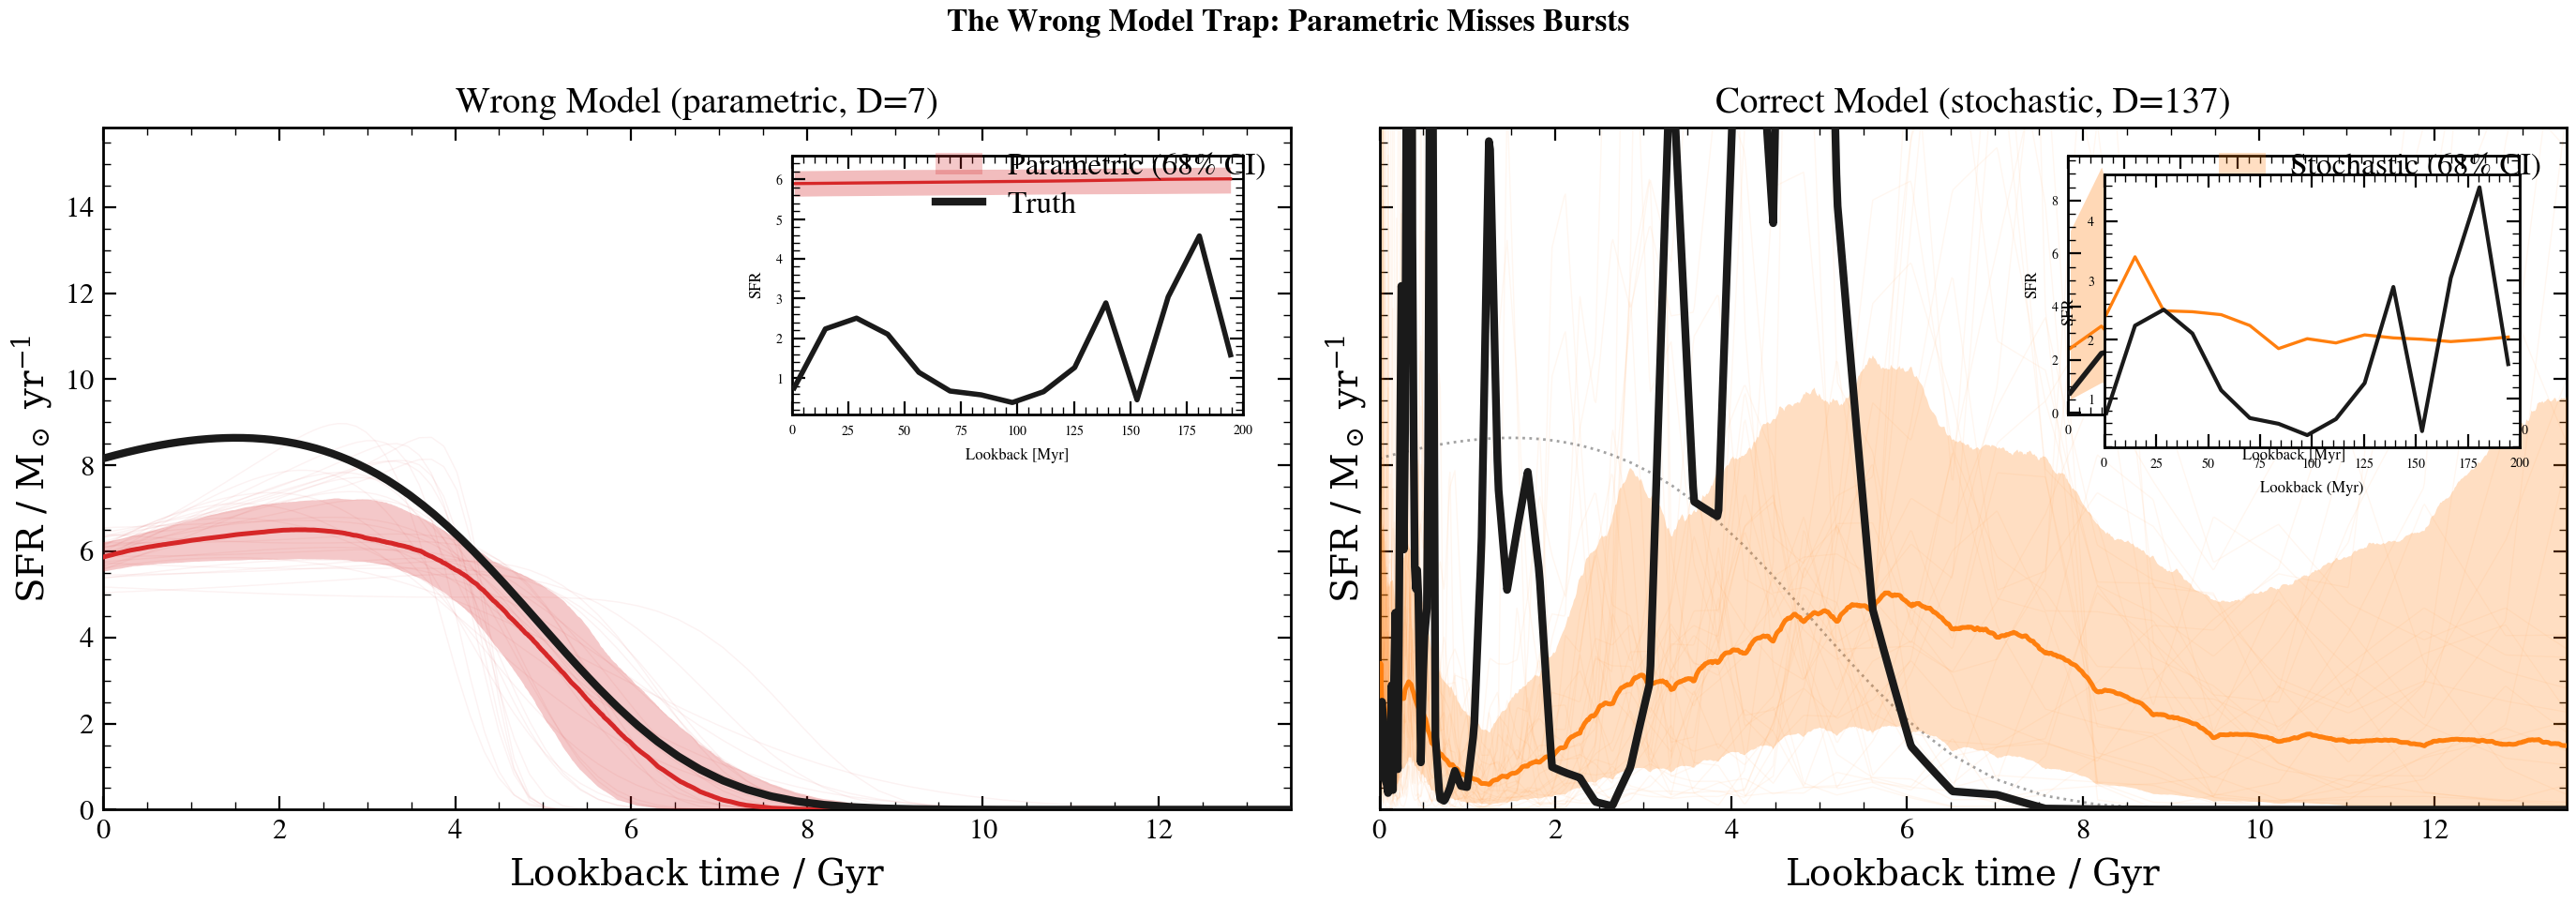

In [15]:
# --- FIGURE 5: Wrong vs correct model (1×2) ---
fig, (ax_wrong, ax_right) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

plot_sfh(
    model_param,
    result_wrong,
    true_params=bursty_true,
    ax=ax_wrong,
    color=COLORS["model"],
    label="Parametric",
    method="MAP",
)
ax_wrong.set_title("Wrong Model (parametric, D=7)")

plot_sfh(
    model_stoch,
    regime_results["Bursty"],
    true_params=bursty_true,
    ax=ax_right,
    color=COLORS["geovi"],
    label="Stochastic",
    method="geoVI",
    show_mean_sfh=True,
)
ax_right.set_title("Correct Model (stochastic, D=137)")

# 200 Myr insets with truth + posterior CI
sfh_bursty = model_stoch.predict_sfh(bursty_true)
t_gyr_b = np.array(sfh_bursty["t_gyr"])
sfr_full_b = np.array(sfh_bursty["sfr_full"])
mask_200 = t_gyr_b < 0.2
t_myr = t_gyr_b[mask_200] * 1e3

inset_data = [
    (ax_wrong, result_wrong, model_param, "sfr_mean", COLORS["model"]),
    (ax_right, regime_results["Bursty"], model_stoch, "sfr_full", COLORS["geovi"]),
]
for ax_panel, res, mod, sfr_key, color in inset_data:
    inset = ax_panel.inset_axes([0.58, 0.58, 0.38, 0.38])
    if res.samples is not None and np.any(mask_200):
        n_draw = min(50, len(next(iter(res.samples.values()))))
        sfh_draws = []
        for j in range(n_draw):
            s_j = {k: res.samples[k][j] for k in res.samples}
            sfh_j = mod.predict_sfh(s_j)
            sfh_draws.append(np.array(sfh_j[sfr_key])[mask_200])
        sfh_arr = np.array(sfh_draws)
        lo, hi = np.percentile(sfh_arr, [16, 84], axis=0)
        med = np.median(sfh_arr, axis=0)
        inset.fill_between(t_myr, lo, hi, color=color, alpha=0.3, lw=0)
        inset.plot(t_myr, med, color=color, lw=1.2)
    inset.plot(t_myr, sfr_full_b[mask_200], color=COLORS["truth"], lw=2, zorder=10)
    inset.set_xlabel("Lookback [Myr]", fontsize=6)
    inset.set_ylabel("SFR", fontsize=6)
    inset.tick_params(labelsize=5)
    inset.set_xlim(0, 200)

fig.suptitle("The Wrong Model Trap: Parametric Misses Bursts", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig05_wrong_model_trap.png"), dpi=150, bbox_inches="tight")
plt.show()

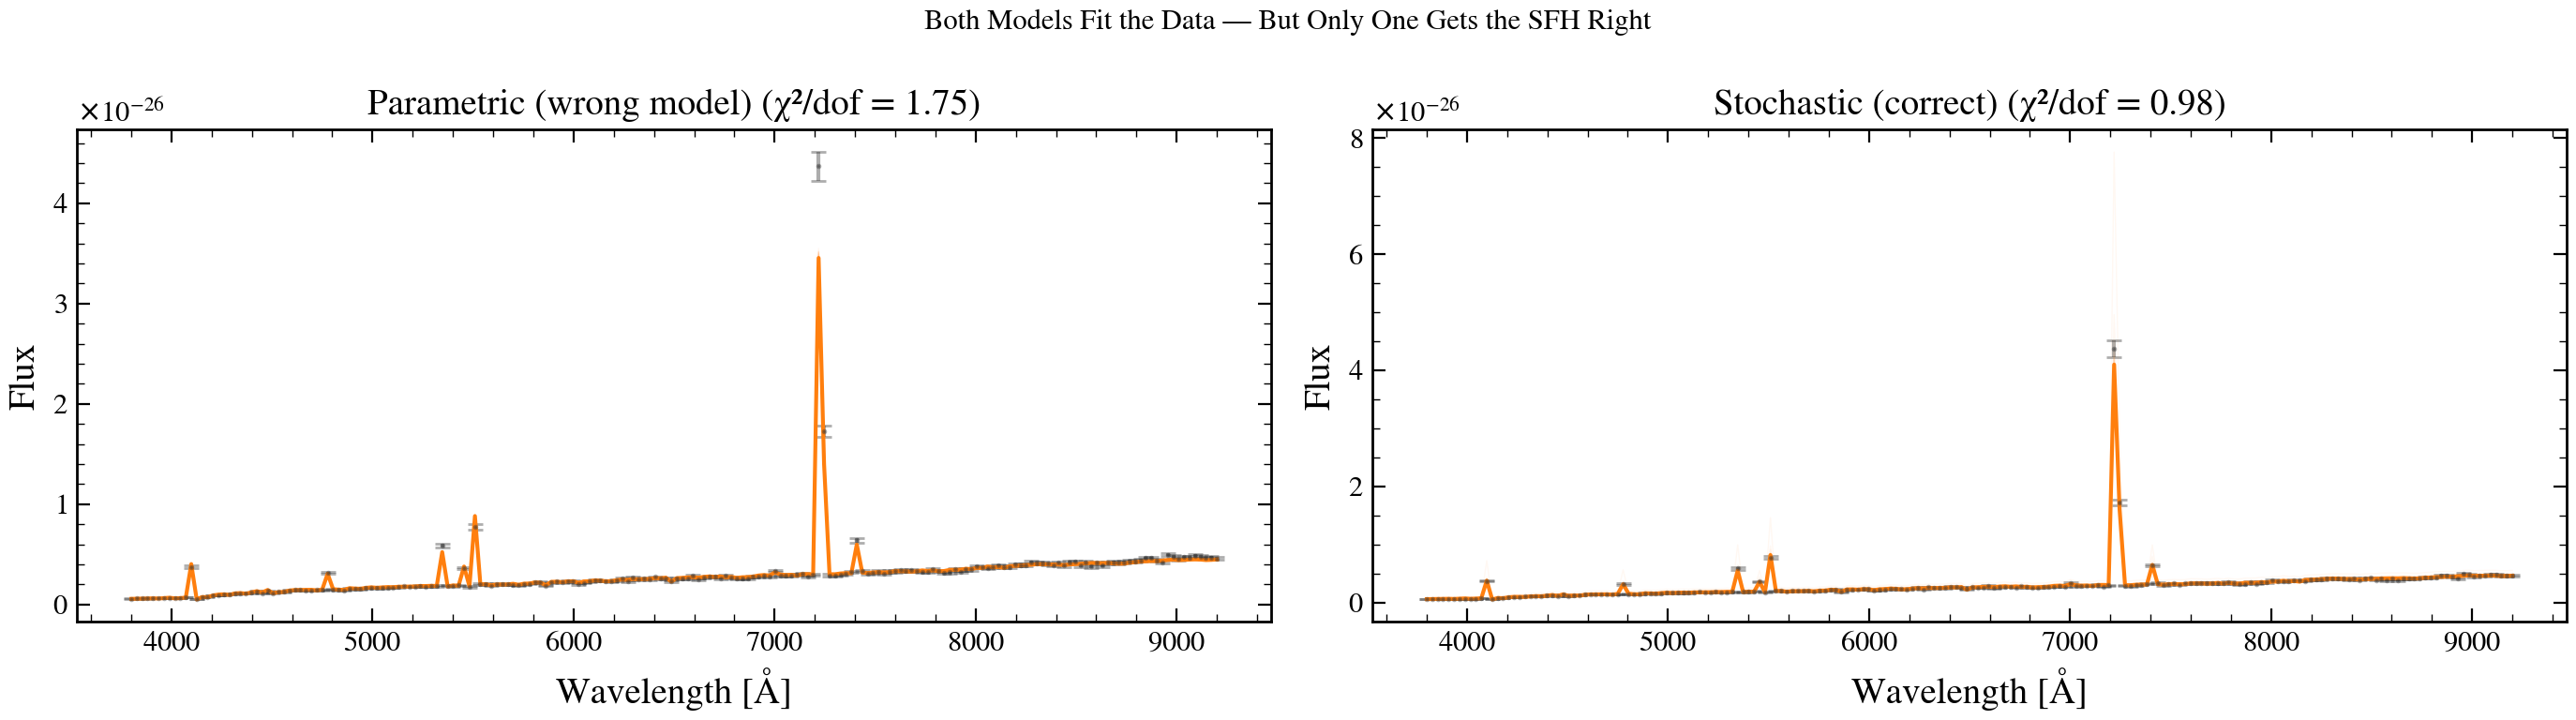

In [16]:
# --- FIGURE 6: Both models fit the data (PPC) ---
fig, (ax_wrong, ax_right) = plt.subplots(1, 2, figsize=(14, 4))

for ax, res, mod, title in [
    (ax_wrong, result_wrong, model_param, "Parametric (wrong model)"),
    (ax_right, regime_results["Bursty"], model_stoch, "Stochastic (correct)"),
]:
    draws = []
    for i in range(30):
        idx = i % len(res.samples[next(iter(res.samples.keys()))])
        p = {k: v[idx] for k, v in res.samples.items()}
        draws.append(np.array(mod.predict_spectrum(p)))
    draws = np.array(draws)
    med = np.median(draws, axis=0)

    ax.errorbar(
        np.array(WAVE_OBS),
        np.array(bursty_mock.flux_obs),
        yerr=np.array(bursty_mock.noise),
        fmt=".",
        ms=2,
        color=COLORS["data"],
        alpha=0.4,
    )
    for d in draws:
        ax.plot(np.array(WAVE_OBS), d, color=COLORS["geovi"], alpha=0.05, lw=0.5)
    ax.plot(np.array(WAVE_OBS), med, color=COLORS["geovi"], lw=1.5)

    chi2 = np.sum(
        ((np.array(bursty_mock.flux_obs) - med) / np.array(bursty_mock.noise)) ** 2
    ) / len(med)
    ax.set_title(f"{title} (χ²/dof = {chi2:.2f})")
    ax.set_xlabel("Wavelength [Å]")
    ax.set_ylabel("Flux")

fig.suptitle("Both Models Fit the Data — But Only One Gets the SFH Right", fontsize=11)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig06_ppc_both_models.png"), dpi=150, bbox_inches="tight")
plt.show()

### Quantitative bias from wrong model

In [17]:
# Compare derived quantities from parametric (wrong) vs stochastic (right) model
# Compute SFH-derived quantities from posterior draws
def _derived_quantities(model, result, n_draws=100):
    """Compute log M*, SFR_100, SFR_10 from posterior draws."""
    log_mstar, sfr_100, sfr_10 = [], [], []
    n_samples = len(result.samples[next(iter(result.samples.keys()))])
    for i in range(min(n_draws, n_samples)):
        p = {k: v[i] for k, v in result.samples.items()}
        sfh = model.predict_sfh(p)
        t_yr = np.array(sfh["t_gyr"]) * 1e9
        sfr = np.array(sfh.get("sfr_full", sfh.get("sfr_mean")))
        # Stellar mass: integral of SFR (trapezoidal)
        dt = np.abs(np.diff(t_yr))
        sfr_mid = 0.5 * (sfr[:-1] + sfr[1:])
        mstar = np.sum(sfr_mid * dt)
        log_mstar.append(np.log10(max(mstar, 1e-30)))
        # SFR averaged over last 100 Myr and 10 Myr
        t_gyr = np.array(sfh["t_gyr"])
        mask_100 = t_gyr < 0.1
        mask_10 = t_gyr < 0.01
        sfr_100.append(float(np.mean(sfr[mask_100])) if np.any(mask_100) else 0.0)
        sfr_10.append(float(np.mean(sfr[mask_10])) if np.any(mask_10) else 0.0)
    return {
        "log M*": np.array(log_mstar),
        "SFR_100": np.array(sfr_100),
        "SFR_10": np.array(sfr_10),
    }


# Truth
sfh_truth = model_stoch.predict_sfh(bursty_true)
t_truth_yr = np.array(sfh_truth["t_gyr"]) * 1e9
sfr_truth = np.array(sfh_truth["sfr_full"])
dt_truth = np.abs(np.diff(t_truth_yr))
sfr_mid_truth = 0.5 * (sfr_truth[:-1] + sfr_truth[1:])
mstar_truth = np.sum(sfr_mid_truth * dt_truth)
t_gyr_truth = np.array(sfh_truth["t_gyr"])
truth_derived = {
    "log M*": np.log10(max(mstar_truth, 1e-30)),
    "SFR_100": float(np.mean(sfr_truth[t_gyr_truth < 0.1])),
    "SFR_10": float(np.mean(sfr_truth[t_gyr_truth < 0.01])),
}

dq_wrong = _derived_quantities(model_param, result_wrong)
dq_right = _derived_quantities(model_stoch, bursty_res)

print(f"\n{'Quantity':<12s} {'Truth':>12s} {'Parametric':>14s} {'Stochastic':>14s}")
print("-" * 56)
for qty_name in ["log M*", "SFR_100", "SFR_10"]:
    truth_val = truth_derived[qty_name]
    wrong_med = np.median(dq_wrong[qty_name])
    right_med = np.median(dq_right[qty_name])
    wrong_lo, wrong_hi = np.percentile(dq_wrong[qty_name], [16, 84])
    right_lo, right_hi = np.percentile(dq_right[qty_name], [16, 84])
    print(
        f"  {qty_name:<10s} {truth_val:12.3f}"
        f" {wrong_med:8.3f} [{wrong_lo:.2f},{wrong_hi:.2f}]"
        f" {right_med:8.3f} [{right_lo:.2f},{right_hi:.2f}]"
    )


Quantity            Truth     Parametric     Stochastic
--------------------------------------------------------
  log M*           10.772   10.526 [10.50,10.55]   10.693 [10.60,10.80]
  SFR_100           1.300    5.839 [5.58,6.24]    3.404 [2.40,4.65]
  SFR_10            0.758    5.798 [5.55,6.20]    2.486 [0.69,6.52]


## Takeaway

A good spectral fit (chi-squared ~ 1) does **not** guarantee correct physical
interpretation. Parametric models smooth over burst features that the
stochastic model captures. Always use the stochastic model when burstiness
matters — especially for recent SFR, sSFR, and emission line predictions.

---
## Section 4 — Why It Matters at JWST: The High-Redshift Stakes

Bursty star formation is most prevalent at high redshift, where JWST is making
new discoveries daily. The wrong-model bias shown above is worst exactly where
it matters most: z > 4, where bursty dwarfs dominate the galaxy population.

In [18]:
ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")

# JWST NIRCam wide filters
jwst_filter_names = [
    "jwst_f090w",
    "jwst_f115w",
    "jwst_f150w",
    "jwst_f200w",
    "jwst_f277w",
    "jwst_f356w",
    "jwst_f410m",
    "jwst_f444w",
]
try:
    obs = Observation(photometry=Photometry.from_names(jwst_filter_names))
    print(f"Loaded {obs.photometry.n_filters} JWST NIRCam filters")
except Exception:
    # Fallback to SDSS if JWST filters not available
    print("JWST filters not available, using SDSS as proxy")
    obs = Observation(
        photometry=Photometry.from_names(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])
    )

Z_HIGH = 6.0

Loaded 8 JWST NIRCam filters


In [19]:
# Stochastic model at z = 6
spec_stoch = Parameters(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.1, 1.0),  # at z=6, universe is ~1 Gyr old
    sfh_tsnorm_width_gyr=Uniform(0.05, 0.5),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    sfh_field_psd_sigma=Uniform(0.1, 4.0),
    sfh_field_psd_tau_myr=Uniform(1.0, 300.0),
    met_logzsol=Uniform(-2.0, -0.5),  # low metallicity at z=6
    dust_tau_bc=Uniform(0.0, 1.0),
    dust_tau_diff=Uniform(0.0, 0.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(Z_HIGH),
    mean_sfh_type=["tsnorm", "field"],
    n_grid=64,  # fewer grid points for young universe
)
model_stoch = Model(spec_stoch, ssp_data, observation=obs)

# Parametric comparison model
spec_param = Parameters(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.1, 1.0),
    sfh_tsnorm_width_gyr=Uniform(0.05, 0.5),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    met_logzsol=Uniform(-2.0, -0.5),
    dust_tau_bc=Uniform(0.0, 1.0),
    dust_tau_diff=Uniform(0.0, 0.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(Z_HIGH),
    mean_sfh_type="tsnorm",
)
model_param = Model(spec_param, ssp_data, observation=obs)

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_79273/1720292307.py:18: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_stoch = Model(spec_stoch, ssp_data, observation=obs)


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_79273/1720292307.py:34: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_param = Model(spec_param, ssp_data, observation=obs)


In [20]:
# Generate bursty mock at z = 6
key = jax.random.PRNGKey(42)
true_p = spec_stoch.sample(key)
true_p = {**true_p}
true_p["sfh_field_psd_sigma"] = jnp.array(2.5)
true_p["sfh_field_psd_tau_myr"] = jnp.array(15.0)

mock = model_stoch.mock(true_p, snr=10.0, key=key)

print(f"z = {Z_HIGH}")
print(f"σ_PS = {float(true_p['sfh_field_psd_sigma']):.1f}")
print(f"τ_PS = {float(true_p['sfh_field_psd_tau_myr']):.0f} Myr")
print(f"N_filters = {obs.photometry.n_filters}")

z = 6.0
σ_PS = 2.5
τ_PS = 15 Myr
N_filters = 8


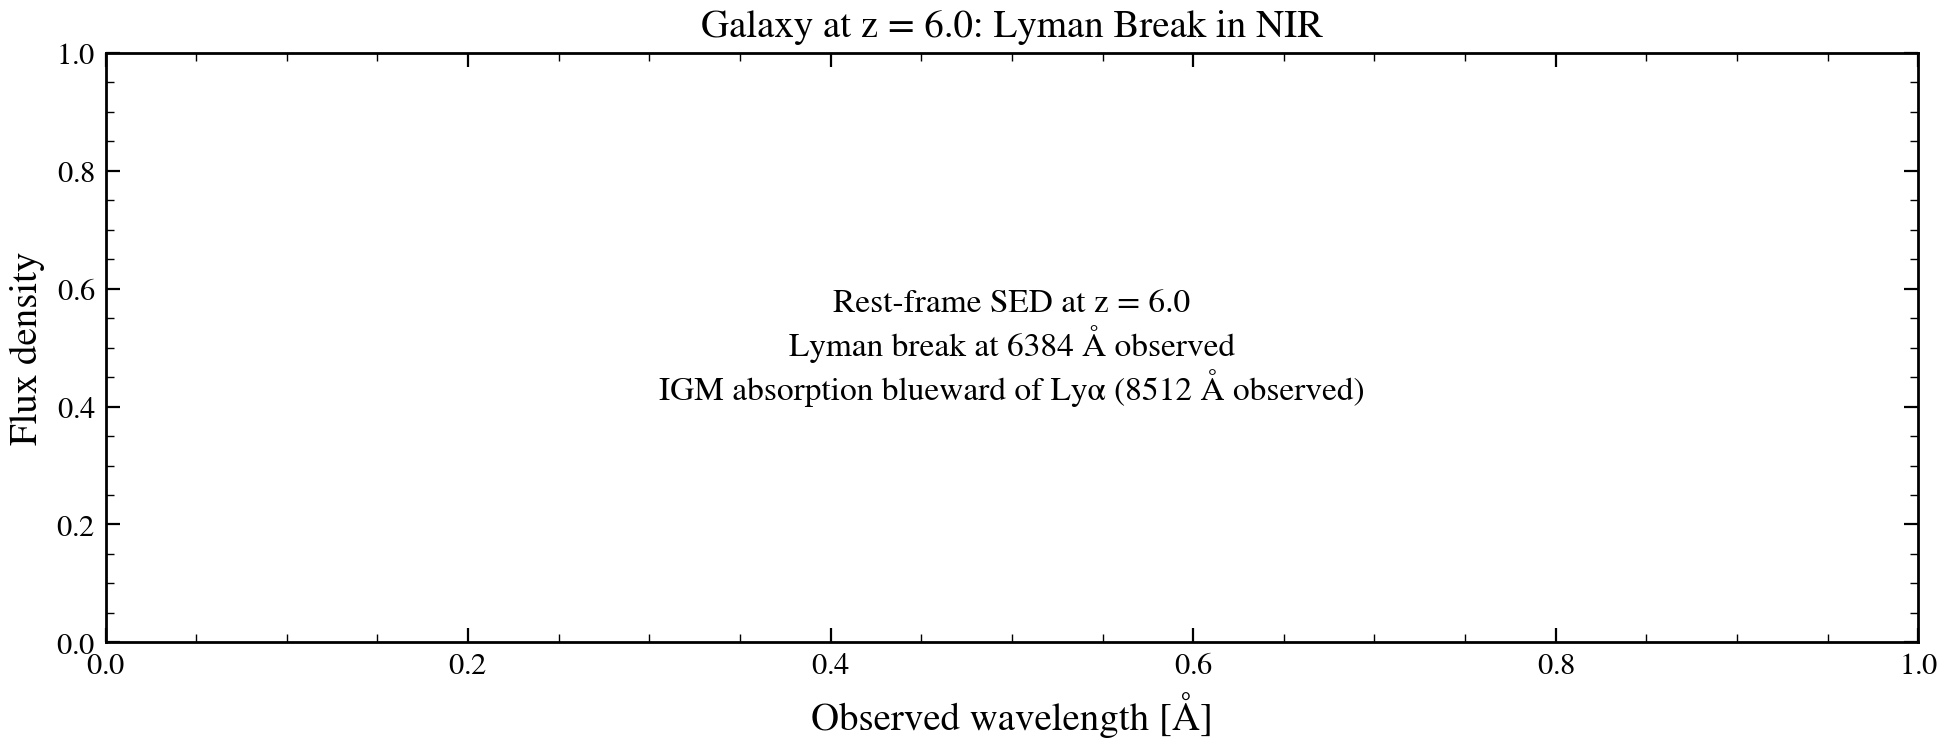

In [21]:
# --- FIGURE 1: Rest-frame SED at z=6 ---
# Predict the full SED
try:
    rest_wave = np.linspace(500, 5000, 500)
    obs_wave = rest_wave * (1 + Z_HIGH)
    # Note: this is a conceptual figure
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.text(
        0.5,
        0.5,
        f"Rest-frame SED at z = {Z_HIGH}\n"
        f"Lyman break at {912 * (1 + Z_HIGH):.0f} Å observed\n"
        f"IGM absorption blueward of Lyα ({1216 * (1 + Z_HIGH):.0f} Å observed)",
        ha="center",
        va="center",
        fontsize=12,
        transform=ax.transAxes,
    )
    ax.set_xlabel("Observed wavelength [Å]")
    ax.set_ylabel("Flux density")
    ax.set_title(f"Galaxy at z = {Z_HIGH}: Lyman Break in NIR")
    fig.tight_layout()
    plt.savefig(os.path.join(FIGDIR, "fig01_sed_z6.png"), dpi=150, bbox_inches="tight")
    plt.show()
except Exception as e:
    print(f"SED plot skipped: {e}")

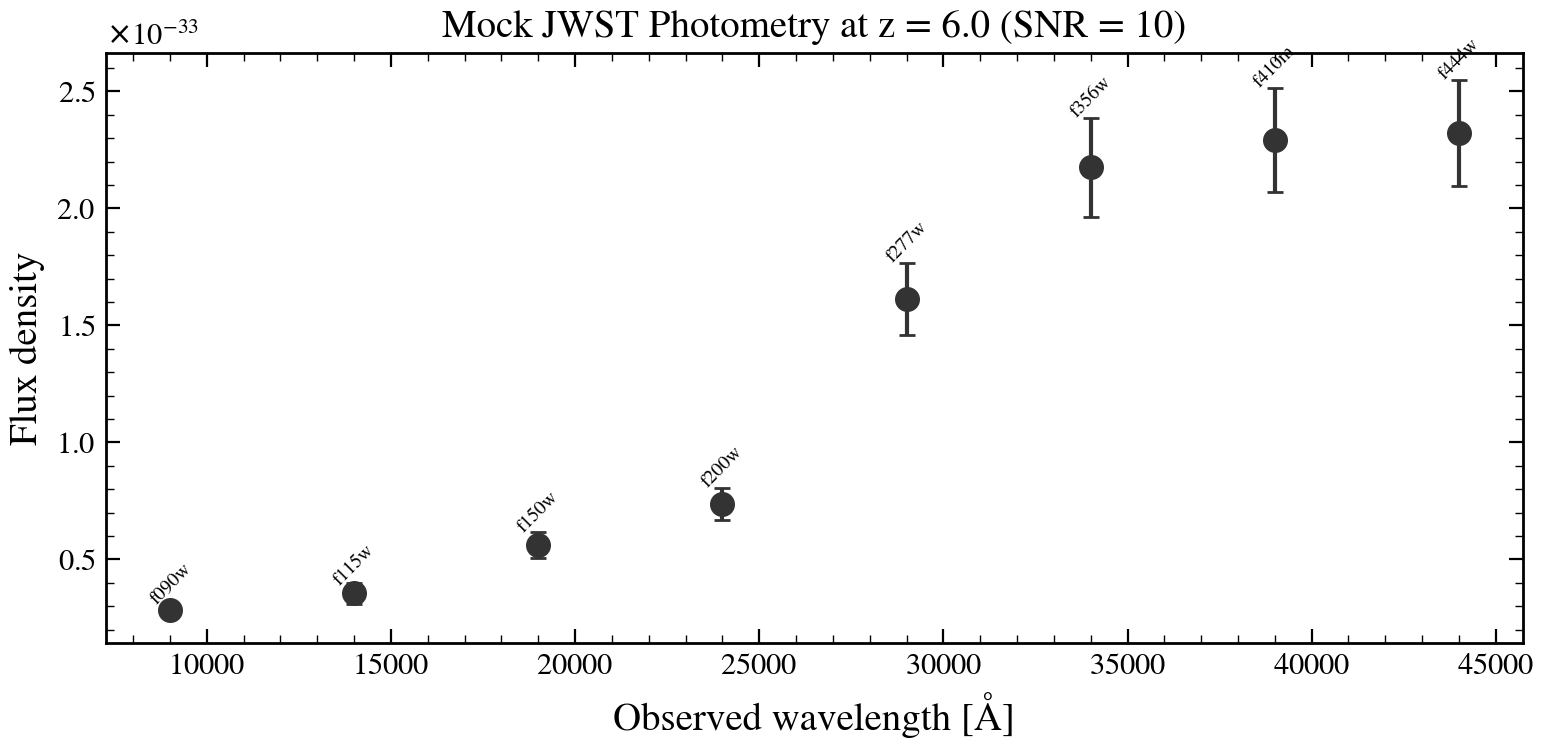

In [22]:
# --- FIGURE 2: Mock JWST photometry ---
fig, ax = plt.subplots(figsize=(8, 4))
n_actual = len(mock.flux_obs)
wave_eff = np.linspace(9000, 44000, n_actual)  # approximate
ax.errorbar(
    wave_eff,
    np.array(mock.flux_obs),
    yerr=np.array(mock.noise),
    fmt="o",
    ms=8,
    color=COLORS["data"],
    capsize=3,
)
n_filt = len(mock.flux_obs)
for i, (w, f) in enumerate(zip(wave_eff[:n_filt], np.array(mock.flux_obs))):
    label = jwst_filter_names[i].split("_")[-1] if i < len(jwst_filter_names) else f"F{i}"
    ax.text(w, f * 1.1, label, ha="center", fontsize=7, rotation=45)
ax.set_xlabel("Observed wavelength [Å]")
ax.set_ylabel("Flux density")
ax.set_title(f"Mock JWST Photometry at z = {Z_HIGH} (SNR = 10)")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig02_mock_jwst_phot.png"), dpi=150, bbox_inches="tight")
plt.show()

In [23]:
# Fit with stochastic model
fitter_stoch = Fitter(model_stoch, mock.flux_obs, mock.noise)
_ = fitter_stoch.run("map", n_steps=500, verbose=False)

# XLA compilation (one-time cost, cached on disk)
t0_compile = time.perf_counter()
fitter_stoch.compile(verbose=False)
t_compile_stoch = time.perf_counter() - t0_compile

# Inference runtime (per-galaxy cost)
t0_run = time.perf_counter()
result_stoch = fitter_stoch.run(
    "vi",
    n_iterations=15,
    n_samples=6,
    n_seeds=5,
    n_posterior_samples=2000,
    verbose=False,
)
t_run_stoch = time.perf_counter() - t0_run

print(f"XLA compile: {t_compile_stoch:.1f}s (one-time, cached)")
print(f"native_geovi runtime: {t_run_stoch:.1f}s")

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


W0405 02:43:51.627583 36250764 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0405 02:43:54.305376 36250764 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0405 02:43:56.957339 36250764 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


/Users/suchethacooray/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Seeds disagree: H = 6.5 ± 1.0 (CV=16%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return run_native_vi(self, key=key, **kwargs)


XLA compile: 73.0s (one-time, cached)
native_geovi runtime: 103.2s


/Users/suchethacooray/Projects/diffsed/src/tengri/inference/fitter.py:2588: UserWarning: Poor fit: chi2/dof=28.2 (expected ~1)
  return run_native_vi(self, key=key, **kwargs)


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_79273/1738175782.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


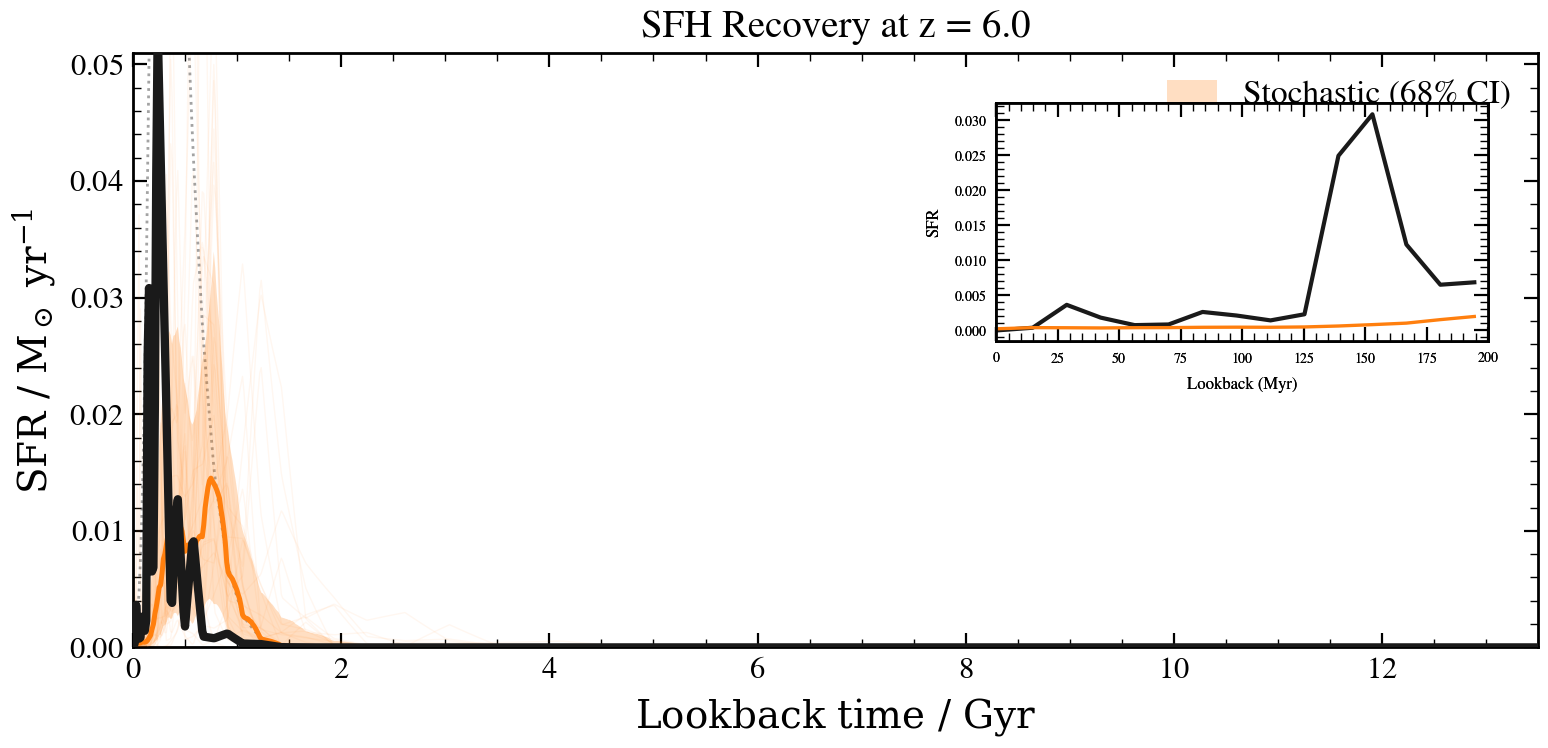

In [24]:
# --- FIGURE 3: SFH recovery at z=6 with 200 Myr inset ---
fig, ax = plt.subplots(figsize=(8, 4))
plot_sfh(
    model_stoch,
    result_stoch,
    true_params=true_p,
    ax=ax,
    color=COLORS["geovi"],
    label="Stochastic",
    method="geoVI",
    show_mean_sfh=True,
)
ax.set_title(f"SFH Recovery at z = {Z_HIGH}")

# 200 Myr inset — zoom into recent burstiness
sfh_true = model_stoch.predict_sfh(true_p)
t_gyr_true = np.array(sfh_true["t_gyr"])
sfr_true = np.array(sfh_true["sfr_full"])
ax_in = add_sfh_inset(ax, t_gyr_true, sfr_true, inset_range_myr=200, color=COLORS["truth"], lw=1.5)
# Overlay posterior median on inset
n_total = len(next(iter(result_stoch.samples.values())))
sfh_draws = []
for i in range(n_total):
    s_i = {k: v[i] for k, v in result_stoch.samples.items()}
    sfh_i = model_stoch.predict_sfh(s_i)
    sfh_draws.append(np.array(sfh_i["sfr_full"]))
sfh_arr = np.array(sfh_draws)
t_gyr_post = np.array(model_stoch.predict_sfh(result_stoch.params)["t_gyr"])
median_sfr = np.median(sfh_arr, axis=0)
t_myr = t_gyr_post * 1e3
mask_inset = t_myr <= 200
if mask_inset.sum() > 2:
    ax_in.plot(t_myr[mask_inset], median_sfr[mask_inset], color=COLORS["geovi"], lw=1.2)

fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig03_sfh_z6.png"), dpi=150, bbox_inches="tight")
plt.show()

## The Burstiness Bias

In [25]:
# Fit same mock with parametric model
fitter_param = Fitter(model_param, mock.flux_obs, mock.noise)
_ = fitter_param.run("map", n_steps=500, verbose=False)

t0_compile_p = time.perf_counter()
fitter_param.compile(verbose=False)
t_compile_param = time.perf_counter() - t0_compile_p

t0_run_p = time.perf_counter()
result_param = fitter_param.run(
    "vi",
    n_iterations=15,
    n_samples=6,
    n_seeds=3,
    n_posterior_samples=2000,
    verbose=False,
)
t_run_param = time.perf_counter() - t0_run_p

print(f"Parametric — compile: {t_compile_param:.1f}s, runtime: {t_run_param:.1f}s")


# Compute stellar mass from both
def compute_mstar(mod, samples, n=200):
    masses = []
    for i in range(min(n, len(next(iter(samples.values()))))):
        p = {k: v[i] for k, v in samples.items()}
        sfh = mod.predict_sfh(p)
        sfr = np.array(sfh["sfr_mean"])
        t = np.array(sfh["t_gyr"])
        dt = np.abs(np.diff(t * 1e9))
        masses.append(np.sum(sfr[:-1] * dt))
    return np.array(masses)


mstar_stoch = compute_mstar(model_stoch, result_stoch.samples)
mstar_param = compute_mstar(model_param, result_param.samples)

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


Parametric — compile: 77.3s, runtime: 78.5s


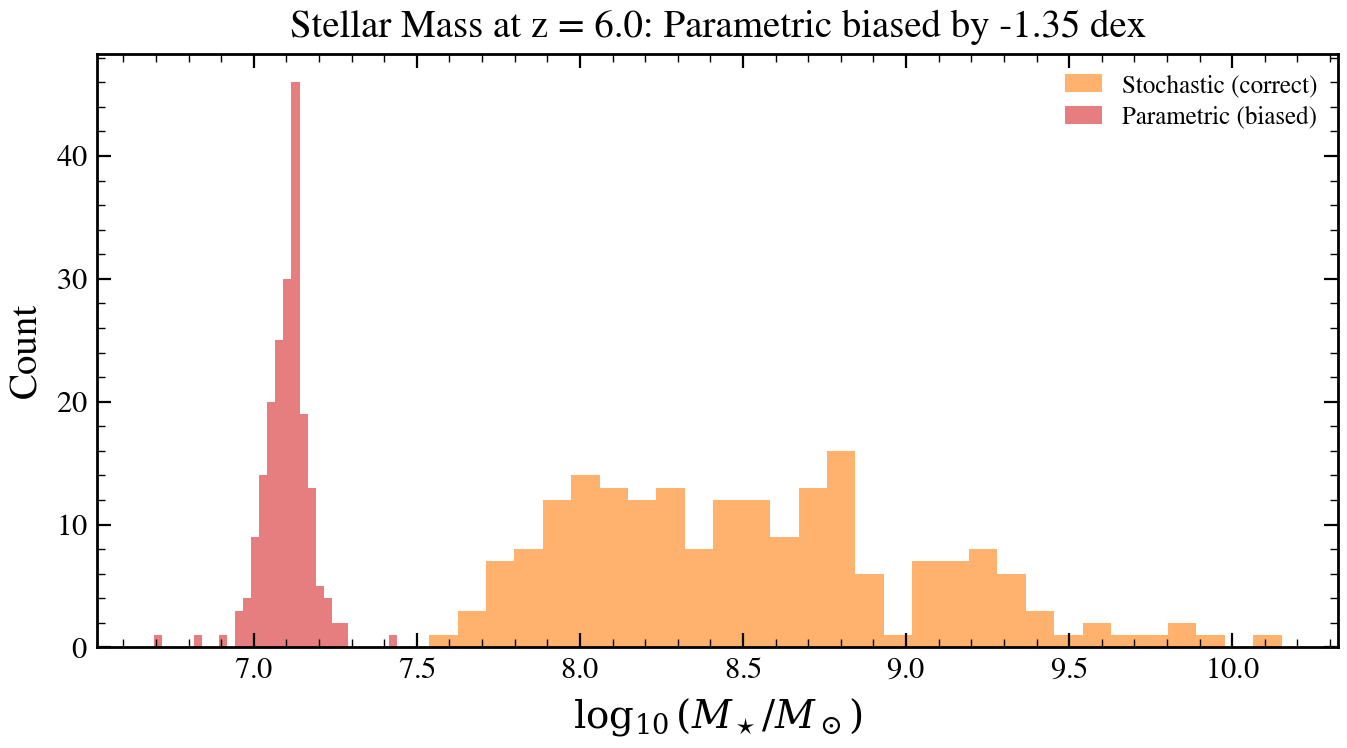

In [26]:
# --- FIGURE 4: M★ posterior comparison ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(
    np.log10(np.clip(mstar_stoch, 1, None)),
    bins=30,
    alpha=0.6,
    color=COLORS["geovi"],
    label="Stochastic (correct)",
)
ax.hist(
    np.log10(np.clip(mstar_param, 1, None)),
    bins=30,
    alpha=0.6,
    color=COLORS["model"],
    label="Parametric (biased)",
)
ax.set_xlabel(r"$\log_{10}(M_\star / M_\odot)$")
ax.set_ylabel("Count")
ax.legend(fontsize=9)

bias = np.median(np.log10(np.clip(mstar_param, 1, None))) - np.median(
    np.log10(np.clip(mstar_stoch, 1, None))
)
ax.set_title(f"Stellar Mass at z = {Z_HIGH}: Parametric biased by {bias:+.2f} dex")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig04_mstar_bias.png"), dpi=150, bbox_inches="tight")
plt.show()

## Convergence Diagnostics

In [27]:
convergence_table({"Stochastic": result_stoch, "Parametric": result_param})

Method           ESS min  ESS med    τ max   Accept   Diverg     Status
-----------------------------------------------------------------------
Stochastic          1453     1566      1.4        —        —         OK
Parametric          1403     1590      1.4        —        —         OK


{'Stochastic': {'ess_min': 1452.889343952722,
  'ess_median': 1566.3696531013227,
  'n_params_low_ess': 0,
  'tau_max_max': 1.3765673265651548,
  'tau_max_median': 1.2769978997881406,
  'n_params_short_chain': 0,
  'converged': True,
  'warnings': []},
 'Parametric': {'ess_min': 1403.3718893919597,
  'ess_median': 1589.6502981122023,
  'n_params_low_ess': 0,
  'tau_max_max': 1.4251389921074604,
  'tau_max_median': 1.2583806311515362,
  'n_params_short_chain': 0,
  'converged': True,
  'warnings': []}}

/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.1

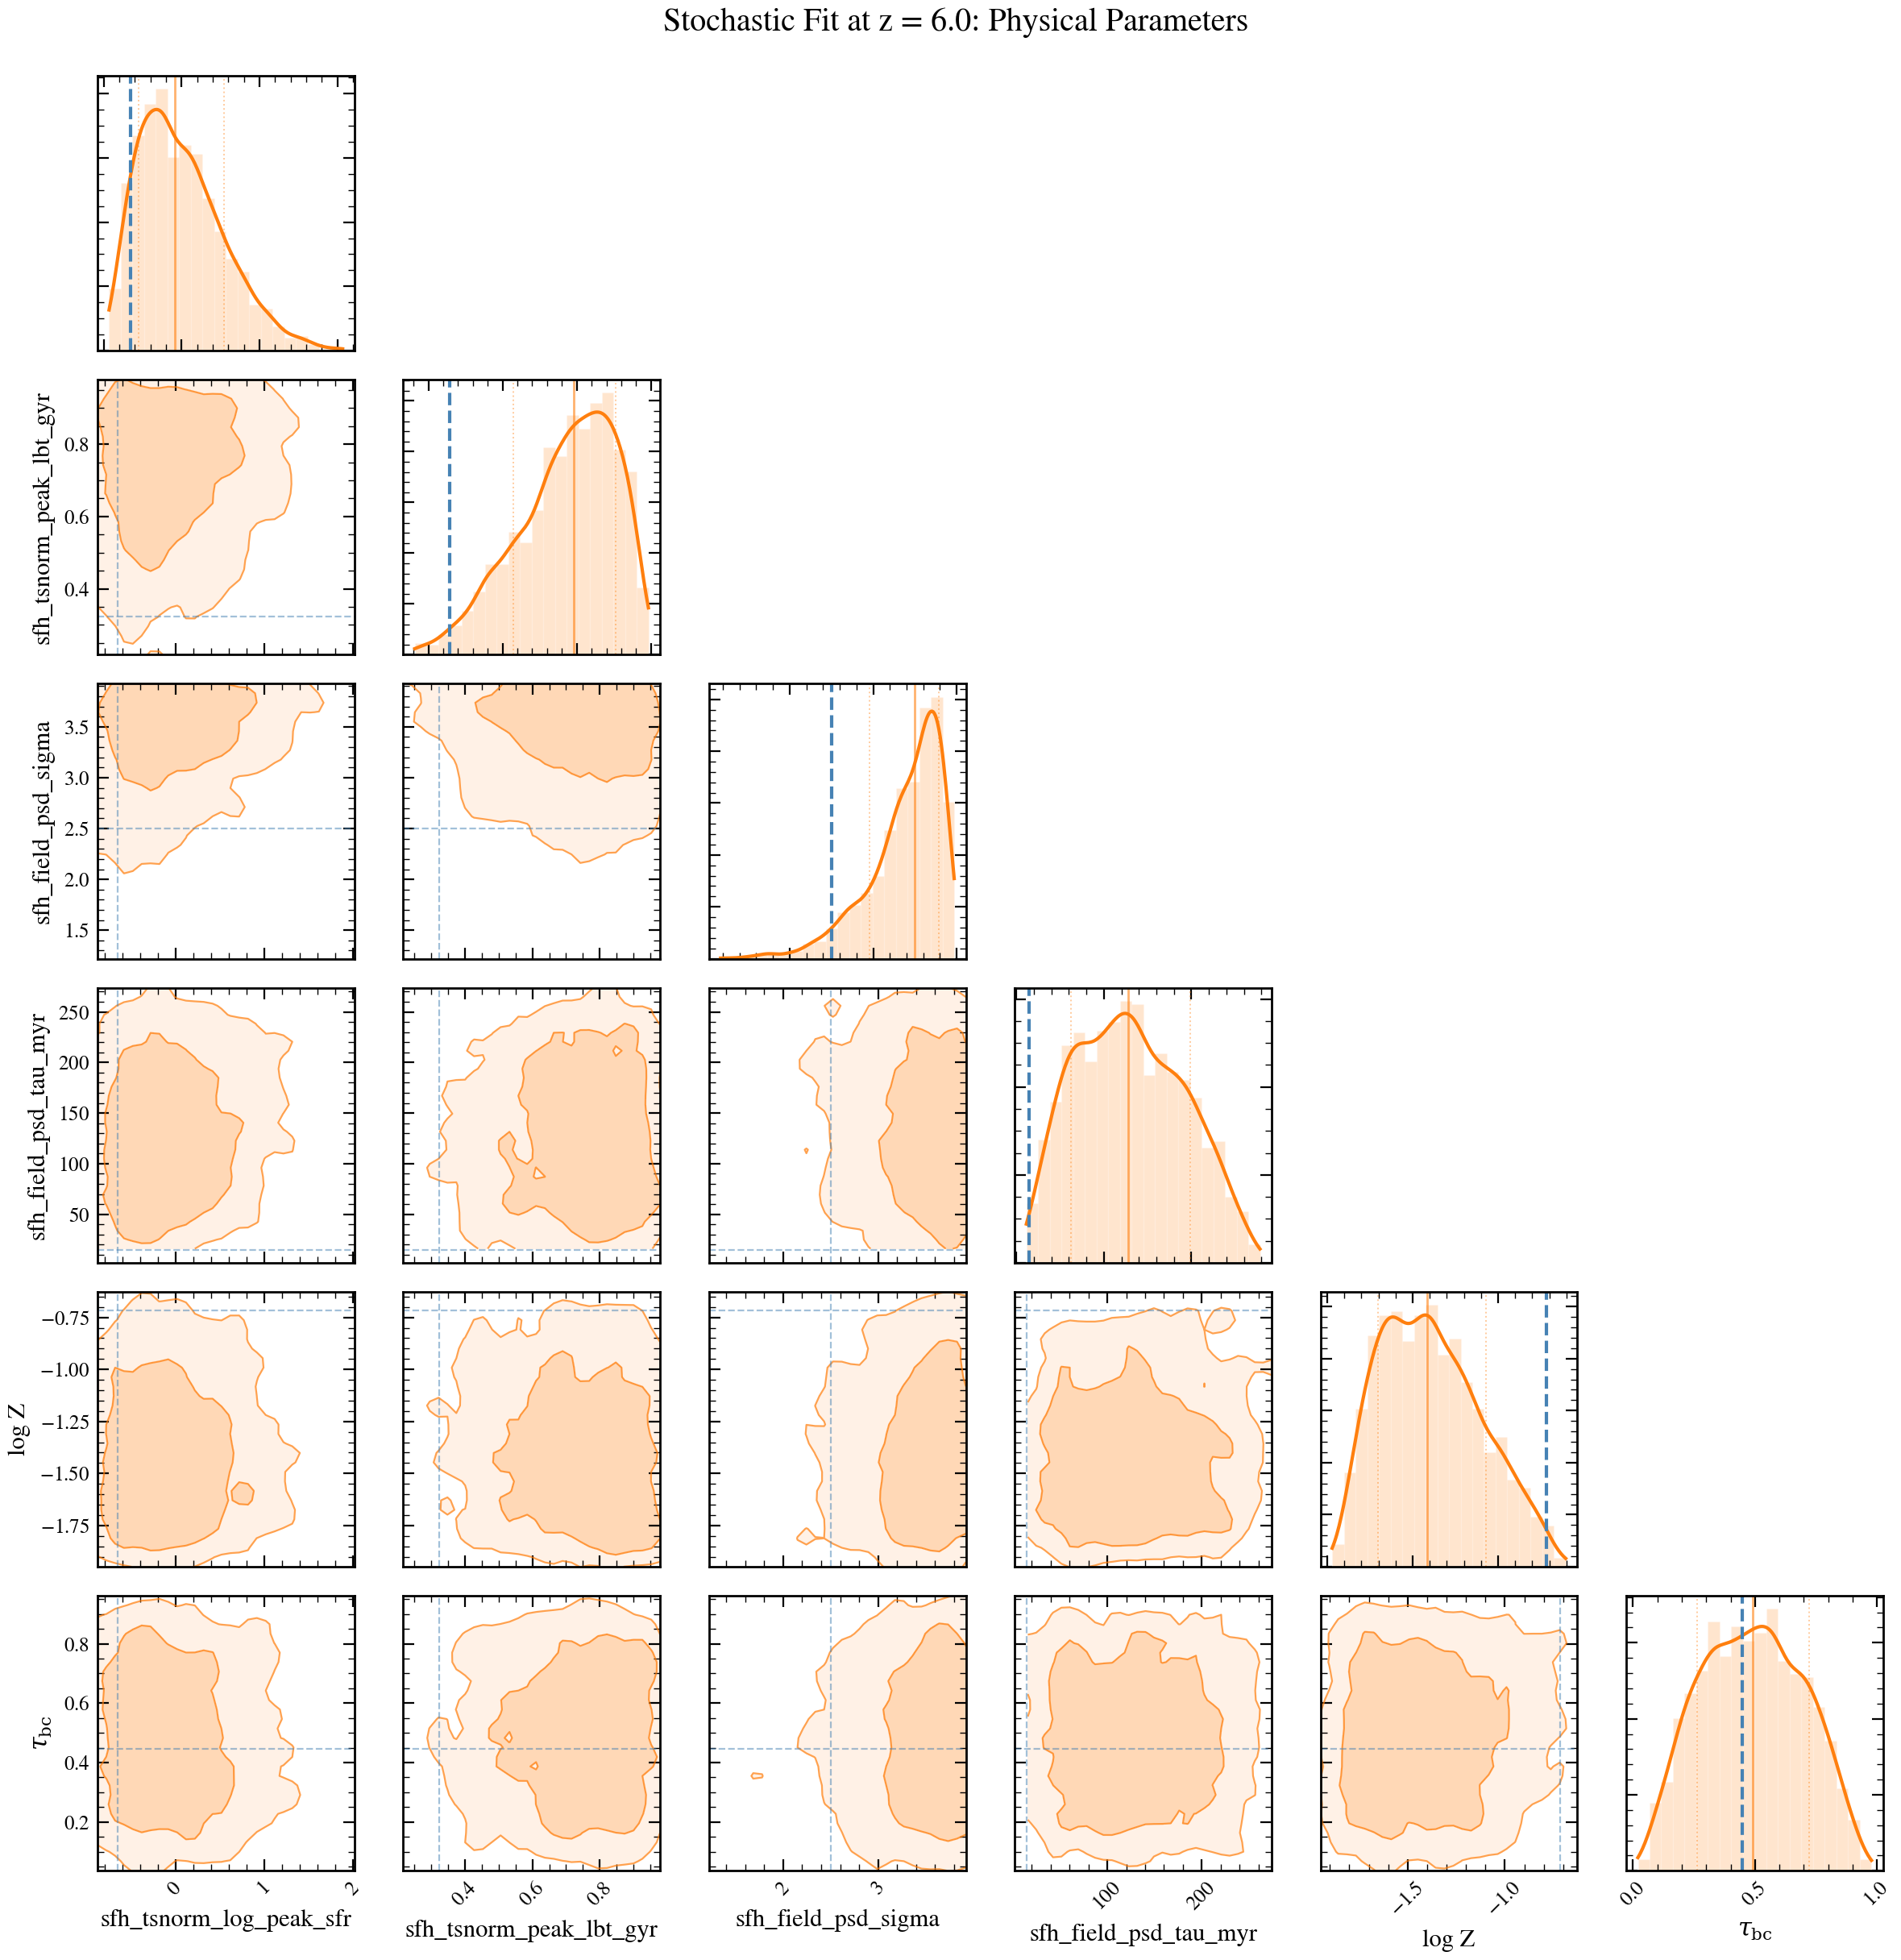

In [28]:
# --- FIGURE 5: Corner plot for stochastic fit (physical params only) ---
corner_params = [
    "sfh_tsnorm_log_peak_sfr",
    "sfh_tsnorm_peak_lbt_gyr",
    "sfh_field_psd_sigma",
    "sfh_field_psd_tau_myr",
    "met_logzsol",
    "dust_tau_bc",
]
fig_corner = safe_corner(
    result_stoch,
    truths=true_p,
    params=corner_params,
    color=COLORS["geovi"],
)
if fig_corner is not None:
    fig_corner.suptitle(
        f"Stochastic Fit at z = {Z_HIGH}: Physical Parameters",
        y=1.02,
    )
    plt.savefig(
        os.path.join(FIGDIR, "fig05_corner_stochastic.png"),
        dpi=150,
        bbox_inches="tight",
    )
plt.show()

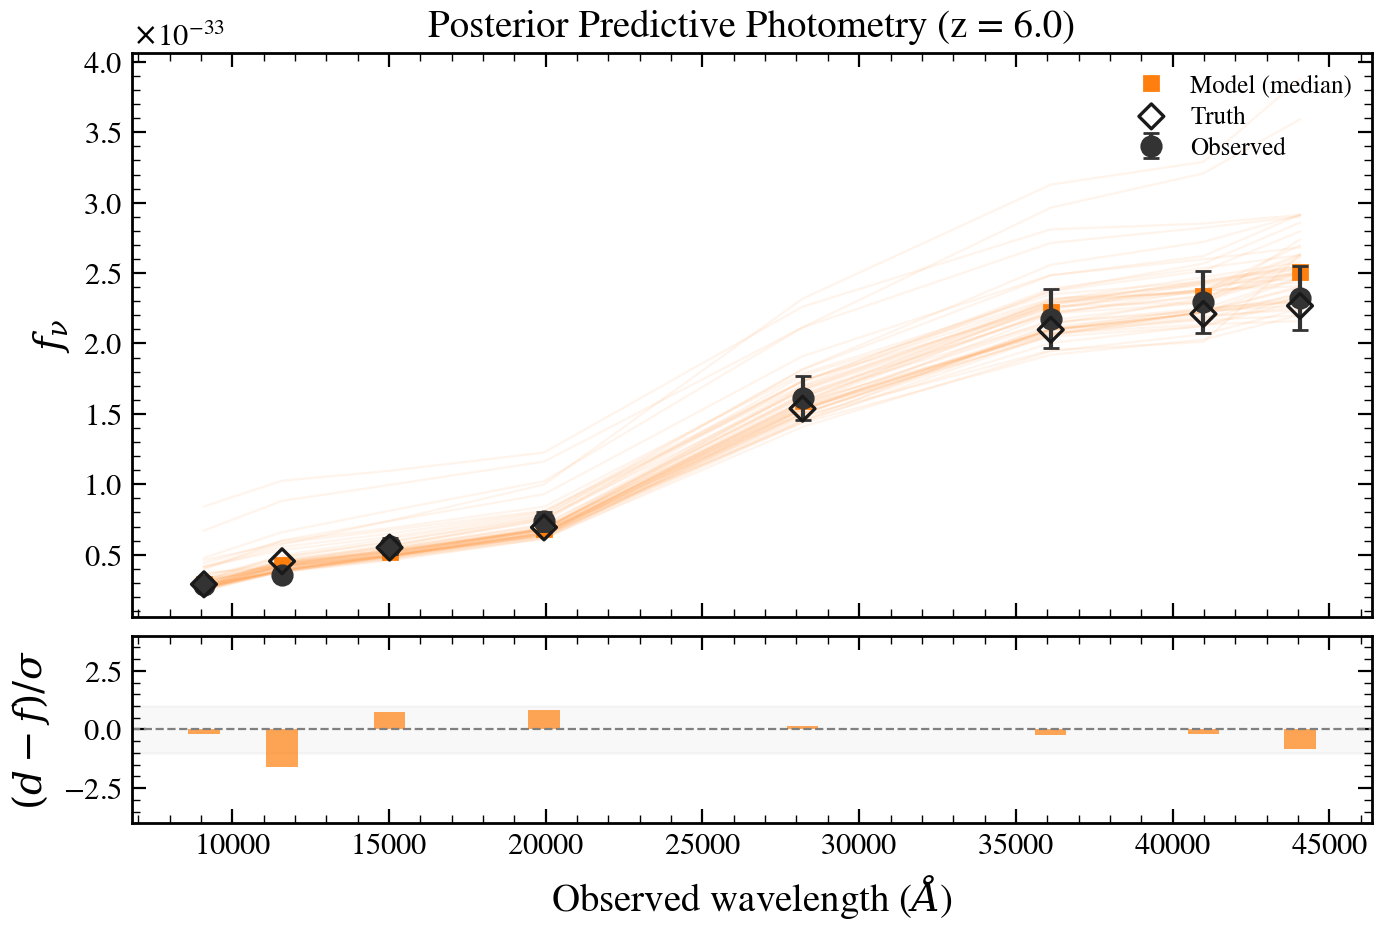

In [29]:
# --- FIGURE 6: Posterior predictive photometry with residuals ---
phot_config = obs.photometry
wave_eff = np.array([float(jnp.mean(fc.wave)) for fc in phot_config.filters])

# Posterior predictive draws
n_draws = 50
posterior_phot = []
for i in range(n_draws):
    idx = i % len(next(iter(result_stoch.samples.values())))
    s_i = {k: v[idx] for k, v in result_stoch.samples.items()}
    posterior_phot.append(np.array(model_stoch.predict_photometry(s_i)))
posterior_phot = np.array(posterior_phot)

# Truth photometry
phot_true = np.array(model_stoch.predict_photometry(true_p))

fig, (ax_top, ax_bot) = plt.subplots(
    2,
    1,
    figsize=(8, 5),
    height_ratios=[3, 1],
    sharex=True,
)
fig.subplots_adjust(hspace=0.05)

# Top: data + posterior draws + truth
for draw in posterior_phot:
    ax_top.plot(wave_eff, draw, "-", color=COLORS["geovi"], alpha=0.08, lw=0.8)
median_pred = np.median(posterior_phot, axis=0)
ax_top.plot(
    wave_eff, median_pred, "s", ms=5, color=COLORS["geovi"], zorder=4, label="Model (median)"
)
ax_top.errorbar(
    wave_eff,
    np.array(mock.flux_obs),
    yerr=np.array(mock.noise),
    fmt="o",
    ms=7,
    color=COLORS["data"],
    capsize=3,
    zorder=5,
    label="Observed",
)
ax_top.scatter(
    wave_eff,
    phot_true,
    marker="D",
    s=40,
    facecolors="none",
    edgecolors=COLORS["truth"],
    linewidths=1.2,
    zorder=6,
    label="Truth",
)
ax_top.set_ylabel(r"$f_\nu$")
ax_top.legend(loc="upper right", fontsize=9)
ax_top.set_title(f"Posterior Predictive Photometry (z = {Z_HIGH})")

# Bottom: residuals
residuals = (np.array(mock.flux_obs) - median_pred) / np.array(mock.noise)
ax_bot.axhline(0, color="0.5", ls="--", lw=0.8)
ax_bot.axhspan(-1, 1, alpha=0.05, color="0.5")
ax_bot.bar(
    wave_eff, residuals, width=np.min(np.diff(wave_eff)) * 0.4, color=COLORS["geovi"], alpha=0.7
)
ax_bot.set_xlabel(r"Observed wavelength ($\AA$)")
ax_bot.set_ylabel(r"$(d - f)/\sigma$")
ax_bot.set_ylim(-4, 4)
plt.setp(ax_top.get_xticklabels(), visible=False)

plt.savefig(
    os.path.join(FIGDIR, "fig06_posterior_predictive.png"),
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [30]:
# --- Parameter recovery table ---
print(f"\n{'Parameter':<30s} {'Truth':>10s} {'Median':>10s} {'68% CI':>20s}")
print("-" * 72)
for pname in corner_params:
    if pname in result_stoch.samples and pname in true_p:
        chain = np.array(result_stoch.samples[pname])
        truth_val = float(true_p[pname])
        med = float(np.median(chain))
        lo, hi = float(np.percentile(chain, 16)), float(np.percentile(chain, 84))
        print(f"{pname:<30s} {truth_val:10.3f} {med:10.3f} [{lo:8.3f}, {hi:8.3f}]")


Parameter                           Truth     Median               68% CI
------------------------------------------------------------------------
sfh_tsnorm_log_peak_sfr            -0.655     -0.089 [  -0.551,    0.541]
sfh_tsnorm_peak_lbt_gyr             0.323      0.740 [   0.537,    0.881]
sfh_field_psd_sigma                 2.500      3.494 [   2.960,    3.788]
sfh_field_psd_tau_myr              15.000    127.496 [  62.792,  198.910]
met_logzsol                        -0.717     -1.417 [  -1.702,   -1.069]
dust_tau_bc                         0.447      0.491 [   0.261,    0.721]


## Summary

At z > 5, burstiness is not optional — it's the dominant mode of star
formation. Parametric models systematically overestimate stellar masses
because they can't capture the rapid fluctuations that boost emission
lines and UV flux. tengri's stochastic model with native_geovi handles
this naturally.

**This is the science case for Paper II.**